In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [101]:
dx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')
dx_df.head()
# Diagnosis codes: 1=CN, 2=MCI, 3=AD

,PHASE,PTID,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,...,DXODES,DXCONFID,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,011_S_0002,2,bl,bl,2005-09-29,1.0,1.0,-4.0,-4.0,...,-4.0,4.0,2,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
1,ADNI1,011_S_0003,3,bl,bl,2005-09-30,3.0,-4.0,-4.0,-4.0,...,-4.0,3.0,4,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
2,ADNI1,011_S_0005,5,bl,bl,2005-09-30,1.0,1.0,-4.0,-4.0,...,-4.0,4.0,6,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
3,ADNI1,011_S_0008,8,bl,bl,2005-09-30,1.0,1.0,-4.0,-4.0,...,-4.0,3.0,8,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
4,ADNI1,022_S_0007,7,bl,bl,2005-10-06,3.0,-4.0,-4.0,-4.0,...,-4.0,4.0,10,10,2005-10-06,NaN,NaN,NaN,NaN,2005-10-06 00:00:00


In [102]:
dem  = pd.read_csv('data/PTDEMOG_17Feb2026.csv') 
dem.columns

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'PTSOURCE',
       'PTGENDER', 'PTDOB', 'PTDOBYY', 'PTHAND', 'PTMARRY', 'PTEDUCAT',
       'PTWORKHS', 'PTWORK', 'PTNOTRT', 'PTRTYR', 'PTHOME', 'PTTLANG',
       'PTPLANG', 'PTADBEG', 'PTCOGBEG', 'PTADDX', 'PTETHCAT', 'PTRACCAT',
       'PTIDENT', 'PTORIENT', 'PTORIENTOT', 'PTENGSPK', 'PTNLANG',
       'PTENGSPKAGE', 'PTCLANG', 'PTLANGSP', 'PTLANGWR', 'PTSPTIM',
       'PTSPOTTIM', 'PTLANGPR1', 'PTLANGSP1', 'PTLANGRD1', 'PTLANGWR1',
       'PTLANGUN1', 'PTLANGPR2', 'PTLANGSP2', 'PTLANGRD2', 'PTLANGWR2',
       'PTLANGUN2', 'PTLANGPR3', 'PTLANGSP3', 'PTLANGRD3', 'PTLANGWR3',
       'PTLANGUN3', 'PTLANGPR4', 'PTLANGSP4', 'PTLANGRD4', 'PTLANGWR4',
       'PTLANGUN4', 'PTLANGPR5', 'PTLANGSP5', 'PTLANGRD5', 'PTLANGWR5',
       'PTLANGUN5', 'PTLANGPR6', 'PTLANGSP6', 'PTLANGRD6', 'PTLANGWR6',
       'PTLANGUN6', 'PTLANGTTL', 'PTETHCATH', 'PTASIAN', 'PTOPI', 'PTBORN',
       'PTBIRPL', 'PTIMMAGE', 'PTIMMWHY', 'PTBIRPR', 'PTBIRGR'

In [108]:
adas = pd.read_csv('data/ADAS_17Feb2026.csv')
print(adas.columns)

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE',
       'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2',
       'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')


In [116]:
def visit_to_months(v):
    if pd.isna(v):
        return np.nan
    v = v.lower()
    if v in ["bl", "sc"]:
        return 0
    if v.startswith("m"):
        return float(v[1:])  # strip the 'm'
    if v.startswith("v"):
        return float(v[1:])  # strip the 'v'
    
    return np.nan

#print(adas["VISCODE"].value_counts())

baseline_codes = ["bl", "4_bl"]
adas["time_months"] = adas["VISCODE"].apply(visit_to_months)
baseline_dates = (
    adas[adas["VISCODE"].isin(baseline_codes)]
    .groupby("RID")["VISDATE"]
    .min()
)

adas_df = adas.merge(
    baseline_dates.rename("baseline_date"),
    on="RID",
    how="left"
)

adas_df["days_since_bl"] = (
    pd.to_datetime(adas_df["VISDATE"]) -
    pd.to_datetime(adas_df["baseline_date"])
)


print(adas_df["days_since_bl"].describe())
print(sum(adas_df["days_since_bl"].isna()))

count                            8767
mean      929 days 17:27:16.363636352
std      1125 days 02:08:30.843923536
min                   0 days 00:00:00
25%                   0 days 00:00:00
50%                 542 days 00:00:00
75%                1457 days 00:00:00
max                7263 days 00:00:00
Name: days_since_bl, dtype: object
4188


In [117]:
print(len(dx_df["RID"]))
print(adas_df["RID"].nunique())
# 4000 (16000) have diagnosis info, 3000 (13000) have ADAS scores


16050
3027


In [118]:
adas_AD_dx = pd.merge(adas_df, dx_df[["RID", "VISCODE", "DIAGNOSIS"]], on=["RID", "VISCODE"], how="left")

# Filter for patients who develop AD at some point
ad_rids = (
    adas_AD_dx
    .loc[(adas_AD_dx["DIAGNOSIS"]== 3.0), "RID"]
    .unique()
)
adas_AD_df = adas_AD_dx[adas_AD_dx["RID"].isin(ad_rids)].copy()

#print(adas_AD_df[(adas_AD_df["PTADDX"].notna()) & (adas_AD_df["PTADDX"] != "9999.0")].head())
print(adas_AD_df["DIAGNOSIS"].value_counts())
adas_AD_df["time_months"] = adas_AD_df["VISCODE"].apply(visit_to_months)
baseline_dates = (
    adas_AD_df
        .sort_values("VISDATE")
        .groupby("RID")["VISDATE"]
        .first()
)
print(adas_AD_df.columns)
adas_AD_df = adas_AD_df.drop(columns=["baseline_date"])
adas_AD_df_bl = adas_AD_df.merge(baseline_dates.rename("baseline_date"), on="RID")

adas_AD_df_bl["days_since_bl"] = (
    pd.to_datetime(adas_AD_df_bl["VISDATE"]) -
    pd.to_datetime(adas_AD_df_bl["baseline_date"])
)

adas_AD_bl = adas_AD_df_bl[adas_AD_df_bl["days_since_bl"]==pd.Timedelta(0)]
print(adas_AD_bl["DIAGNOSIS"].value_counts())

DIAGNOSIS
3.0    2607
2.0    1576
1.0     237
Name: count, dtype: int64
Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE',
       'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2',
       'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp',
       'time_months', 'baseline_date', 'days_since_bl', 'DIAGNOSIS'],
      dtype='object')
DIAGNOSIS
3.0    471
2.0    404
1.0     43
Name: count, dtype: int64


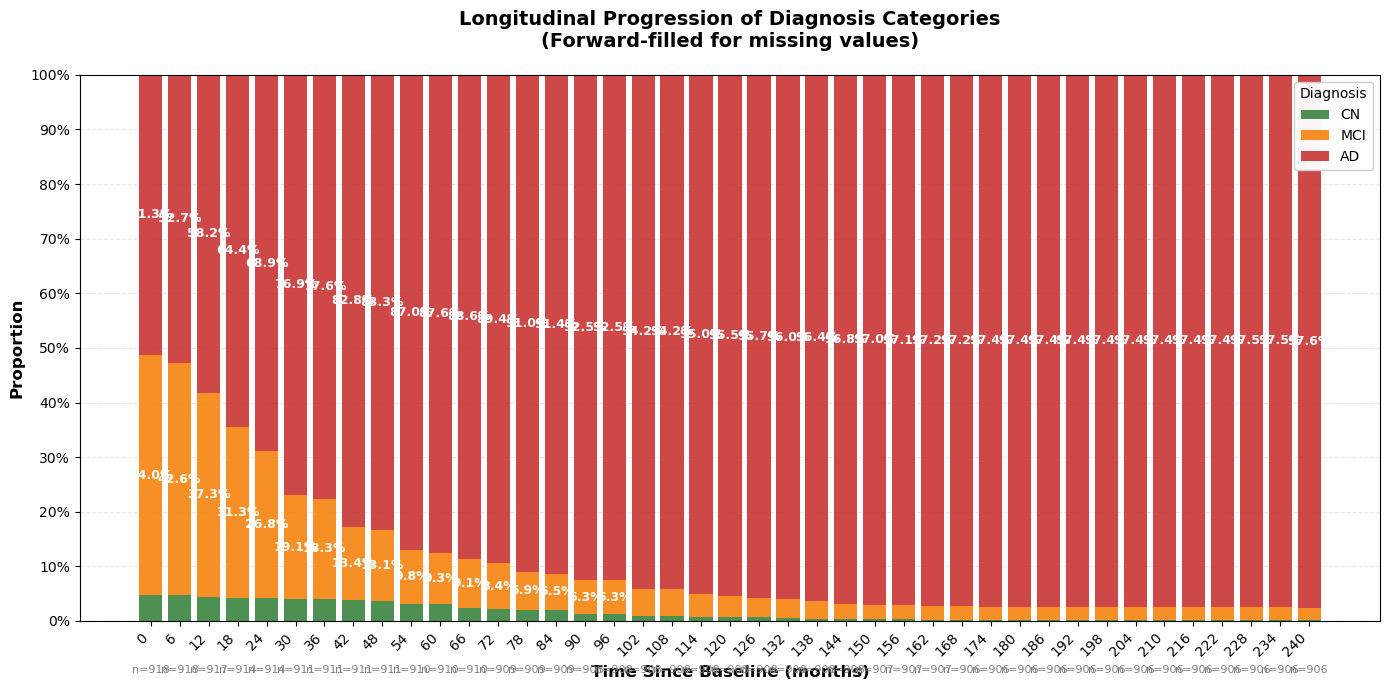

     time        CN       MCI        AD  n_patients
0     0.0  0.046841  0.440087  0.513072         918
1     6.0  0.046841  0.425926  0.527233         918
2    12.0  0.044711  0.372955  0.582334         917
3    18.0  0.042670  0.312910  0.644420         914
4    24.0  0.042670  0.268053  0.689278         914
5    30.0  0.039517  0.190999  0.769484         911
6    36.0  0.040615  0.183315  0.776070         911
7    42.0  0.038419  0.133919  0.827662         911
8    48.0  0.036224  0.130626  0.833150         911
9    54.0  0.031868  0.097802  0.870330         910
10   60.0  0.030769  0.093407  0.875824         910
11   66.0  0.023077  0.091209  0.885714         910
12   72.0  0.022002  0.083608  0.894389         909
13   78.0  0.020902  0.069307  0.909791         909
14   84.0  0.020902  0.064906  0.914191         909
15   90.0  0.012115  0.062775  0.925110         908
16   96.0  0.012115  0.062775  0.925110         908
17  102.0  0.008811  0.049559  0.941630         908
18  108.0  0

In [9]:
#Plotting preportions of each diagnosis:

def create_longitudinal_diagnosis_chart(adas_AD_df_bl):
    """
    Create a longitudinal bar chart showing proportion of AD, MCI, and CN over time
    with forward-filling for missing values.
    """
    
    # Create time bins (e.g., every 6 months)
    max_days = adas_AD_df_bl["days_since_bl"].dt.days.max()
    time_bins = np.arange(0, max_days + 180, 180)  # 6-month intervals
    time_labels = [f"{int(days/30)} mo" for days in time_bins]
    
    # Get unique patients
    all_patients = adas_AD_df_bl["RID"].unique()
    
    # Diagnosis mapping for clarity
    diagnosis_map = {
        1.0: "CN",
        2.0: "MCI", 
        3.0: "AD"
    }
    
    # Prepare data for each time bin
    proportions_over_time = []
    
    for i, time_point in enumerate(time_bins):
        # For each patient, get their diagnosis at or before this time point
        diagnoses_at_timepoint = []
        
        for rid in all_patients:
            patient_data = adas_AD_df_bl[adas_AD_df_bl["RID"] == rid].copy()
            patient_data = patient_data.sort_values("days_since_bl")
            
            # Get all visits up to and including this time point
            valid_visits = patient_data[
                patient_data["days_since_bl"].dt.days <= time_point
            ]
            
            if len(valid_visits) > 0:
                # Take the most recent diagnosis (forward-fill)
                most_recent_diagnosis = valid_visits.iloc[-1]["DIAGNOSIS"]
                if pd.notna(most_recent_diagnosis):
                    diagnoses_at_timepoint.append(most_recent_diagnosis)
        
        # Calculate proportions
        if len(diagnoses_at_timepoint) > 0:
            diagnosis_counts = pd.Series(diagnoses_at_timepoint).value_counts()
            total = len(diagnoses_at_timepoint)
            
            proportions = {
                "time": time_point / 30,  # Convert to months
                "CN": diagnosis_counts.get(1.0, 0) / total,
                "MCI": diagnosis_counts.get(2.0, 0) / total,
                "AD": diagnosis_counts.get(3.0, 0) / total,
                "n_patients": total
            }
            proportions_over_time.append(proportions)
    
    # Convert to DataFrame for plotting
    plot_df = pd.DataFrame(proportions_over_time)
    
    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x_positions = np.arange(len(plot_df))
    width = 0.8
    
    # Colors for each diagnosis
    colors = {
        "CN": "#2E7D32",  # Green
        "MCI": "#F57C00",  # Orange
        "AD": "#C62828"    # Red
    }
    
    # Create stacked bars
    bottom = np.zeros(len(plot_df))
    
    for diagnosis in ["CN", "MCI", "AD"]:
        values = plot_df[diagnosis].values
        ax.bar(x_positions, values, width, bottom=bottom, 
               label=diagnosis, color=colors[diagnosis], alpha=0.85)
        
        # Add percentage labels in the middle of each segment
        for i, (val, bot) in enumerate(zip(values, bottom)):
            if val > 0.05:  # Only show label if segment is large enough
                ax.text(i, bot + val/2, f'{val*100:.1f}%', 
                       ha='center', va='center', fontsize=9, fontweight='bold',
                       color='white')
        
        bottom += values
    
    # Customize the plot
    ax.set_xlabel('Time Since Baseline (months)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Proportion', fontsize=12, fontweight='bold')
    ax.set_title('Longitudinal Progression of Diagnosis Categories\n(Forward-filled for missing values)', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Set x-axis
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"{int(t)}" for t in plot_df["time"]], rotation=45, ha='right')
    
    # Set y-axis to show proportions
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_yticklabels([f'{int(y*100)}%' for y in np.arange(0, 1.1, 0.1)])
    
    # Add grid
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add legend
    ax.legend(title='Diagnosis', loc='upper right', framealpha=0.95, fontsize=10)
    
    # Add sample size annotations
    for i, (x, n) in enumerate(zip(x_positions, plot_df["n_patients"])):
        ax.text(x, -0.08, f'n={int(n)}', ha='center', va='top', 
               fontsize=8, color='gray', transform=ax.get_xaxis_transform())
    
    plt.tight_layout()
    
    return fig, plot_df


# Usage:
# fig, proportions_df = create_longitudinal_diagnosis_chart(adas_AD_df_bl)
# plt.savefig('longitudinal_diagnosis_proportions.png', dpi=300, bbox_inches='tight')
# plt.show()

# Print summary statistics
# print("\nProportions over time:")
# print(proportions_df)
# print("\nVerification - all proportions sum to 1:")
# print(proportions_df[["CN", "MCI", "AD"]].sum(axis=1))
fig, proportions_df = create_longitudinal_diagnosis_chart(adas_AD_df_bl)
plt.savefig('diagnosis_progression.png', dpi=300, bbox_inches='tight')
plt.show()

# View the underlying data
print(proportions_df)

In [10]:
"""print(df.head())
df = pd.merge(df, dx_df[["RID", "VISCODE", "DIAGNOSIS"]], on=["RID", "VISCODE"], how="left")
baseline_dates = (
    df
        .sort_values("VISDATE")
        .groupby("RID")["VISDATE"]
        .first()
)
print(df.columns)
#df = df.drop(columns=["baseline_date"])
df_bl = df.merge(baseline_dates.rename("baseline_date"), on="RID")

df_bl["days_since_bl"] = (
    pd.to_datetime(df_bl["VISDATE"]) -
    pd.to_datetime(df_bl["baseline_date"])
)
fig, proportions_df = create_longitudinal_diagnosis_chart(df_bl)
plt.savefig('diagnosis_progression.png', dpi=300, bbox_inches='tight')
plt.show()

# View the underlying data
print(proportions_df)"""

'print(df.head())\ndf = pd.merge(df, dx_df[["RID", "VISCODE", "DIAGNOSIS"]], on=["RID", "VISCODE"], how="left")\nbaseline_dates = (\n    df\n        .sort_values("VISDATE")\n        .groupby("RID")["VISDATE"]\n        .first()\n)\nprint(df.columns)\n#df = df.drop(columns=["baseline_date"])\ndf_bl = df.merge(baseline_dates.rename("baseline_date"), on="RID")\n\ndf_bl["days_since_bl"] = (\n    pd.to_datetime(df_bl["VISDATE"]) -\n    pd.to_datetime(df_bl["baseline_date"])\n)\nfig, proportions_df = create_longitudinal_diagnosis_chart(df_bl)\nplt.savefig(\'diagnosis_progression.png\', dpi=300, bbox_inches=\'tight\')\nplt.show()\n\n# View the underlying data\nprint(proportions_df)'

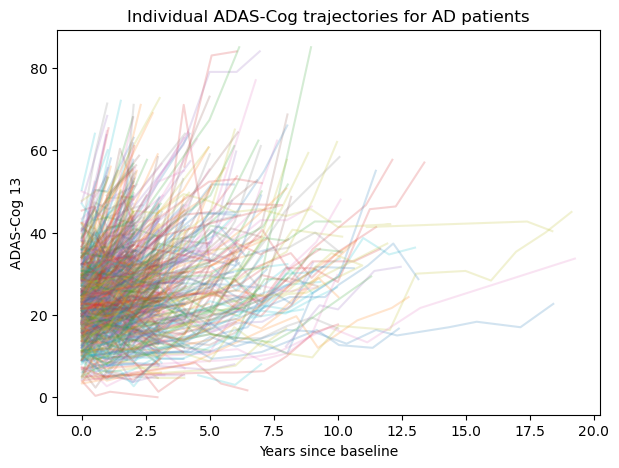

In [11]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
sample_rids = adas_AD_df["RID"].unique()

plt.figure(figsize=(7,5))
for rid in sample_rids:
    sub = adas_AD_df[adas_AD_df["RID"] == rid]
    plt.plot(sub["days_since_bl"].dt.days / 365.25, sub["TOTAL13"], alpha=0.2)

plt.xlabel("Years since baseline")
plt.ylabel("ADAS-Cog 13")
plt.title("Individual ADAS-Cog trajectories for AD patients")
plt.show()

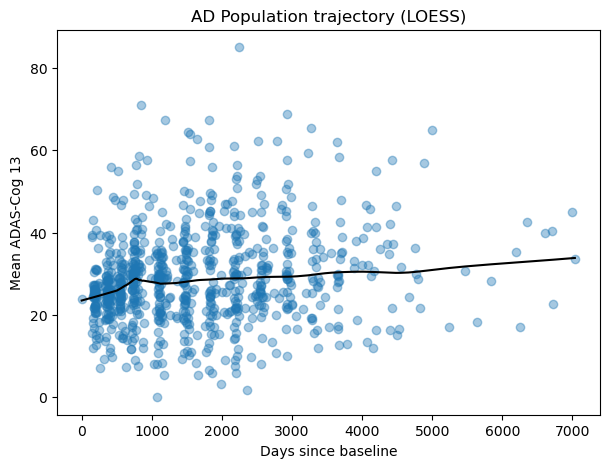

In [12]:
from statsmodels.nonparametric.smoothers_lowess import lowess


mean_by_time = (
    adas_AD_df
    .groupby("days_since_bl")["TOTAL13"]
    .mean()
    .reset_index()
)
mean_by_time["days"] = mean_by_time["days_since_bl"].dt.days

smoothed = lowess(
    mean_by_time["TOTAL13"],
    mean_by_time["days"],
    frac=0.3
)

plt.figure(figsize=(7,5))
plt.scatter(mean_by_time["days"], mean_by_time["TOTAL13"], alpha=0.4)
plt.plot(smoothed[:,0], smoothed[:,1], color="black")
plt.xlabel("Days since baseline")
plt.ylabel("Mean ADAS-Cog 13")
plt.title("AD Population trajectory (LOESS)")
plt.show()

In [13]:
medhist = pd.read_csv('data/MEDHIST_17Feb2026.csv')
recmhist = pd.read_csv('data/RECMHIST_17Feb2026.csv')
print(medhist.columns)
print(recmhist.columns)
print(len(recmhist["MHDESC"]))
mask_year = recmhist["MHDESC"].str.contains(r"\b\d{4}\b", regex=True, na=False)

mask_year.sum()

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'MHSOURCE',
       'MHPSYCH', 'MH2NEURL', 'MH3HEAD', 'MH4CARD', 'MH5RESP', 'MH6HEPAT',
       'MH7DERM', 'MH8MUSCL', 'MH9ENDO', 'MH10GAST', 'MH11HEMA', 'MH12RENA',
       'MH13ALLE', 'MH14ALCH', 'MH14AALCH', 'MH14BALCH', 'MH14CALCH',
       'MH15DRUG', 'MH15ADRUG', 'MH15BDRUG', 'MH16SMOK', 'MH16ASMOK',
       'MH16BSMOK', 'MH16CSMOK', 'MH17MALI', 'MH18SURG', 'MH19OTHR', 'ID',
       'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'],
      dtype='object')
Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'RECNO',
       'MHNUM', 'MHDESC', 'MHDTONSET', 'MHCUR', 'MHSTAB', 'ID', 'SITEID',
       'USERDATE', 'USERDATE2', 'update_stamp'],
      dtype='object')
30810


np.int64(12388)

In [14]:
CNS_KEYWORDS = [
    "stroke", "cerebrovascular", "tia",
    "depression", "anxiety", "bipolar",
    "insomnia", "sleep",
    "head injury", "tbi", "concussion",
    "epilepsy", "seizure"
]

PERIPHERAL_KEYWORDS = [
    "hypertension", "hyperlipidemia", "diabetes",
    "atrial fibrillation", "afib",
    "coronary", "ischemic heart",
    "anemia",
    "hypothyroid", "hyperthyroid",
    "kidney", "renal",
    "hepatitis", "liver",
    "copd", "asthma", "pulmonary",
    "osteoporosis",
    "hearing loss",
    "cancer", "malignancy",
    "gastro", "ulcer", "reflux",
    "obesity",
    "cataract"
]

In [15]:
def classify_condition(desc):
    if pd.isna(desc):
        return None
    d = desc.lower()
    if any(k in d for k in CNS_KEYWORDS):
        return "CNS"
    if any(k in d for k in PERIPHERAL_KEYWORDS):
        return "Peripheral"
    return "Other"

recmhist["comorb_group"] = recmhist["MHDESC"].apply(classify_condition)

In [16]:
comorb_counts = (
    recmhist
    .groupby(["RID", "VISCODE", "comorb_group"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

In [17]:
medhist["CNS_flag"] = (
    medhist["MHPSYCH"].fillna(0) +
    medhist["MH2NEURL"].fillna(0) +
    medhist["MH3HEAD"].fillna(0)
) > 0

medhist["Peripheral_flag"] = (
    medhist["MH4CARD"].fillna(0) +
    medhist["MH9ENDO"].fillna(0) +
    medhist["MH12RENA"].fillna(0) +
    medhist["MH17MALI"].fillna(0)
) > 0

In [72]:
UTI_KEYWORDS = [
    "urinary tract infection",
    "uti",
    "bladder infection",
    "cystitis",
    "urosepsis",
    "pyelonephritis",
    "urinary infection",
    "recurrent uti"
]

Z867_KEYWORDS = [
    "history of stroke",
    "history of tia",
    "prior stroke",
    "previous stroke",
    "prior tia",
    "cva",
    "transient ischemic attack",
    "history of myocardial infarction",
    "previous mi",
    "prior mi",
    "ischemic heart disease",
    "coronary artery disease",
    "cad",
    "peripheral vascular disease",
    "pvd",
    "vascular disease"
]

Z864_KEYWORDS = [
    "alcohol abuse",
    "alcohol dependence",
    "alcoholism",
    "substance abuse",
    "drug abuse",
    "drug dependence",
    "opioid dependence",
    "cocaine use",
    "heroin use",
    "illicit drug use",
    "history of substance abuse"
]

SLEEP_KEYWORDS = [
    "insomnia",
    "sleep disorder",
    "sleep disturbance",
    "poor sleep",
    "sleep apnea",
    "obstructive sleep apnea",
    "osa",
    "hypersomnia",
    "sleep fragmentation",
    "restless legs"
]

DENTAL_KEYWORDS = [
    "periodontitis",
    "gingivitis",
    "gum disease",
    "dental abscess",
    "tooth infection",
    "tooth loss",
    "edentulous",
    "poor dentition",
    "dental caries",
    "tooth decay"
]

In [160]:
T2_DIABETES_KEYWORDS = [
    "type 2 diabetes",
    "type ii diabetes",
    "t2dm",
    "t2d",
    "diabetes mellitus type 2",
    "non-insulin dependent diabetes",
    "niddm",
    "adult onset diabetes",
    "diabetes",
    "diabetic",
    "hyperglycemia",
    "insulin resistance",
    "metformin",        # strong proxy if used carefully
    "oral hypoglycemic",
    "oral antidiabetic",
]

ATRIAL_FIBRILLATION_KEYWORDS = [
    "atrial fibrillation",
    "atrial flutter",
    "af",
    "afib",
    "a-fib",
    "a fib",
    "paroxysmal atrial fibrillation",
    "persistent atrial fibrillation",
    "permanent atrial fibrillation",
    "chronic atrial fibrillation",
    "auricular fibrillation",
]

HEART_FAILURE_KEYWORDS = [
    "heart failure",
    "cardiac failure",
    "congestive heart failure",
    "chf",
    "systolic heart failure",
    "diastolic heart failure",
    "left ventricular failure",
    "right ventricular failure",
    "left heart failure",
    "right heart failure",
    "hfref",
    "hfpef",
    "cardiomyopathy",
    "dilated cardiomyopathy",
    "ischemic cardiomyopathy",
]

ISCHEMIC_HEART_DISEASE_KEYWORDS = [
    "ischemic heart disease",
    "ischaemic heart disease",
    "ihd",
    "coronary artery disease",
    "cad",
    "coronary heart disease",
    "chd",
    "myocardial infarction",
    "mi",
    "heart attack",
    "acute coronary syndrome",
    "acs",
    "angina",
    "unstable angina",
    "stable angina",
    "angina pectoris",
    "coronary artery bypass",
    "cabg",
    "percutaneous coronary intervention",
    "pci",
    "stent",
    "angioplasty",
]

STROKE_KEYWORDS = [
    "stroke",
    "cerebrovascular accident",
    "cva",
    "cerebral infarction",
    "cerebral infarct",
    "ischemic stroke",
    "ischaemic stroke",
    "haemorrhagic stroke",
    "hemorrhagic stroke",
    "tia",
    "transient ischemic attack",
    "transient ischaemic attack",
    "brain attack",
    "subarachnoid hemorrhage",
    "subarachnoid haemorrhage",
    "intracerebral hemorrhage",
    "intracerebral haemorrhage",
    "cerebrovascular disease",
    "lacunar infarct",
    "lacunar stroke",
]

In [161]:

CNS_KEYWORDS = {
    'cerebrovascular': ['stroke', 'cerebrovascular', 'tia', 'transient ischemic', 'cva'],
    'insomnia': ['insomnia', 'sleep disorder'],
    'anxiety': ['anxiety', 'anxious'],
    'depression': ['depression', 'depressive', 'depressed'],
    'head_injury': ['head injury', 'tbi', 'traumatic brain', 'concussion', 'head trauma']
}

PERIPHERAL_KEYWORDS = {
    'hypertension': ['hypertension', 'high blood pressure', 'htn'],
    'hyperlipidemia': ['hyperlipidemia', 'hypercholesterolemia', 'high cholesterol', 'dyslipidemia'],
    'diabetes': ['diabetes', 'diabetic', 'dm', 'niddm', 'iddm'],
    'atrial_fibrillation': ['atrial fibrillation', 'afib', 'a fib', 'a-fib'],
    'coronary': ['coronary', 'ischemic heart', 'ihd', 'cad', 'coronary artery', 'myocardial infarction', 'mi', 'heart attack'],
    'anemia': ['anemia', 'anaemia'],
    'hypothyroid': ['hypothyroid', 'thyroid'],
    'skin_inflammatory': ['psoriasis', 'eczema', 'dermatitis', 'skin inflammation'],
    'pulmonary': ['copd', 'asthma', 'pulmonary', 'emphysema', 'chronic bronchitis', 'respiratory', 'lung disease'],
    'kidney': ['kidney', 'renal', 'ckd', 'chronic kidney'],
    'hepatitis': ['hepatitis', 'liver disease', 'cirrhosis'],
    'osteoporosis': ['osteoporosis', 'bone density'],
    'hearing_loss': ['hearing loss', 'deaf', 'hearing impair'],
    'cancer': ['cancer', 'malignancy', 'carcinoma', 'tumor', 'neoplasm'],
    'gastrointestinal': ['gastro', 'ulcer', 'reflux', 'gerd', 'ibs', 'crohn', 'colitis', 'diverticulitis'],
    'cataract': ['cataract'],
}

def classify_condition_detailed(desc):
    """
    Classify condition into CNS, Peripheral, or Other
    Returns tuple: (category, specific_condition)
    """
    if pd.isna(desc):
        return None, None
    
    d = desc.lower()
    
    # Check CNS conditions
    for condition, keywords in CNS_KEYWORDS.items():
        if any(k in d for k in keywords):
            return "CNS", condition
    
    # Check Peripheral conditions
    for condition, keywords in PERIPHERAL_KEYWORDS.items():
        if any(k in d for k in keywords):
            return "Peripheral", condition
    
    return "Other", None

SPECIFIC_KEYWORDS = {
    "UTI": UTI_KEYWORDS,
    "Z867": Z867_KEYWORDS,
    "Z864": Z864_KEYWORDS,
    "Sleep": SLEEP_KEYWORDS,
    "Dental": DENTAL_KEYWORDS,
    # --- Dove et al. cardiometabolic ---
    "CM_diabetes": T2_DIABETES_KEYWORDS,
    "CM_afib": ATRIAL_FIBRILLATION_KEYWORDS,
    "CM_heart_failure": HEART_FAILURE_KEYWORDS,
    "CM_ihd": ISCHEMIC_HEART_DISEASE_KEYWORDS,
    "CM_stroke": STROKE_KEYWORDS,}

def classify_specific(desc):
    if pd.isna(desc):
        return None
    
    d = desc.lower()
    d = d.replace("hx of", "history of")
    d = d.replace("h/o", "history of")
    
    for category, keywords in SPECIFIC_KEYWORDS.items():
        if any(k in d for k in keywords):
            return category
    
    return None

recmhist["specific_flag"] = recmhist["MHDESC"].apply(classify_specific)

# Apply classification
recmhist["comorb_category"] = recmhist["MHDESC"].apply(
    lambda x: classify_condition_detailed(x)[0]
)
recmhist["specific_condition"] = recmhist["MHDESC"].apply(
    lambda x: classify_condition_detailed(x)[1]
)

specific_flags_visit = (
    recmhist[recmhist["specific_flag"].notna()]
    .assign(flag=1)
    .pivot_table(
        index=["RID", "VISCODE"],
        columns="specific_flag",
        values="flag",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)
# For obesity, you need to calculate from VITALS data
# vitals["BMI"] = vitals["WEIGHT"] / (vitals["HEIGHT"]/100)**2  # if height in cm
# vitals["obesity"] = vitals["BMI"] >= 30

# Count unique conditions per participant per visit
# This is important - you want to count DISTINCT conditions, not total entries
comorb_counts = (
    recmhist[recmhist["comorb_category"].isin(["CNS", "Peripheral"])]
    .groupby(["RID", "VISCODE", "comorb_category", "specific_condition"])
    .size()
    .reset_index(name="count")
    .groupby(["RID", "VISCODE", "comorb_category"])
    .agg(
        n_conditions=("specific_condition", "nunique"),
        total_entries=("count", "sum")
    )
    .reset_index()
)

# Create wide format
comorb_wide = comorb_counts.pivot_table(
    index=["RID", "VISCODE"],
    columns="comorb_category",
    values="n_conditions",
    fill_value=0
).reset_index()

# Calculate total multimorbidity burden
comorb_wide["total_conditions"] = (
    comorb_wide.get("CNS", 0) + 
    comorb_wide.get("Peripheral", 0)
)

# Categorize burden as in the paper
def categorize_burden(n):
    if n <= 2:
        return "Low"
    elif n <= 5:
        return "Medium"
    else:
        return "High"

comorb_wide["burden_category"] = comorb_wide["total_conditions"].apply(categorize_burden)

# For CNS burden: 0 vs 1+ (as paper did)
comorb_wide["CNS_burden"] = comorb_wide["CNS"].apply(lambda x: "0" if x == 0 else "1+")

# For Peripheral burden: 0-1 vs 2+ (as paper did)
comorb_wide["Peripheral_burden"] = comorb_wide["Peripheral"].apply(
    lambda x: "0-1" if x <= 1 else "2+"
)
print(recmhist["specific_flag"].value_counts(dropna=False))

specific_flag
None                24913
CM_ihd               3947
Sleep                 566
CM_afib               361
CM_diabetes           324
CM_stroke             273
Z867                  225
UTI                   117
Z864                   50
CM_heart_failure       32
Dental                  2
Name: count, dtype: int64


In [162]:
comorb_wide = comorb_wide.merge(
    specific_flags_visit,
    on=["RID", "VISCODE"],
    how="left"
)

# Replace NaNs (participants without that condition)
CM_COLS = ["CM_diabetes", "CM_afib", "CM_heart_failure", "CM_ihd", "CM_stroke"]

for col in ["UTI", "Z867", "Z864", "Sleep", "Dental"] + CM_COLS:
    if col in comorb_wide.columns:
        comorb_wide[col] = comorb_wide[col].fillna(0)

# CM flag: 1 if any cardiometabolic condition is present
comorb_wide["CM"] = (
    comorb_wide[[c for c in CM_COLS if c in comorb_wide.columns]]
    .max(axis=1)
    .clip(upper=1)
    .astype(int)
)

In [164]:
print(comorb_wide[[ "CM"]].value_counts(dropna=False))

CM
1     2220
0      696
Name: count, dtype: int64


### Add demographics

In [86]:
demographics = pd.read_csv('data/PTDEMOG_17Feb2026.csv')

df = comorb_wide.merge(demographics, left_on=["RID", "VISCODE"], right_on=["RID", "VISCODE"], how="left")
print(df["VISDATE"].head(5))
df["age_at_visit"] = (pd.to_datetime(df["VISDATE"]) - pd.to_datetime(df["PTDOB"])).dt.days / 365.25


0    2005-08-18
1           NaN
2    2005-08-17
3    2010-09-22
4    2011-09-19
Name: VISDATE, dtype: object


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/3069834342.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["age_at_visit"] = (pd.to_datetime(df["VISDATE"]) - pd.to_datetime(df["PTDOB"])).dt.days / 365.25


In [87]:
def visit_to_months(v):
    if pd.isna(v):
        return np.nan
    v = v.lower()
    if v in ["bl", "sc"]:
        return 0
    if v.startswith("m"):
        return float(v[1:])  # strip the 'm'
    if v.startswith("v"):
        return float(v[1:])  # strip the 'v'
    
    return np.nan


df["time_months"] = df["VISCODE"].apply(visit_to_months)

In [143]:
apoe_df = pd.read_csv("data/APOERES_17Feb2026.csv")
apoe_df["CARRIER"] = apoe_df["GENOTYPE"].isin(["2/4","3/4","4/4"])
apoe_df["HOMO"] = apoe_df["GENOTYPE"].isin(["4/4"])
print(apoe_df["GENOTYPE"].value_counts())
print(sum(apoe_df["HOMO"]))
apoe_df.head()

GENOTYPE
3/3    1529
3/4    1096
4/4     297
2/3     239
2/4      81
2/2      11
Name: count, dtype: int64
297


,PHASE,PTID,RID,VISCODE,GENOTYPE,APTESTDT,APVOLUME,APRECEIVE,APAMBTEMP,APRESAMP,APUSABLE,ID,SITEID,USERDATE,USERDATE2,update_stamp,CARRIER,HOMO
0,ADNI1,011_S_0002,2,sc,3/3,2005-08-22,5.0,1.0,1.0,0.0,1.0,4.0,107.0,2005-08-23,NaN,2005-08-23 00:00:00,False,False
1,ADNI1,011_S_0003,3,sc,3/4,2005-08-22,10.0,1.0,1.0,0.0,1.0,6.0,107.0,2005-08-23,NaN,2005-08-23 00:00:00,True,False
2,ADNI1,022_S_0004,4,sc,3/3,2005-08-22,9.2,1.0,1.0,0.0,1.0,8.0,10.0,2005-08-23,NaN,2005-08-23 00:00:00,False,False
3,ADNI1,011_S_0005,5,sc,3/3,2005-08-29,10.0,1.0,1.0,0.0,1.0,10.0,107.0,2005-08-29,NaN,2005-08-29 00:00:00,False,False
4,ADNI1,022_S_0007,7,sc,3/4,2005-09-05,9.0,1.0,1.0,0.0,1.0,12.0,10.0,2005-09-06,NaN,2005-09-06 00:00:00,True,False


In [89]:
df = df.merge(apoe_df[["RID", "CARRIER", "HOMO"]], on="RID", how="left")

In [90]:
import pandas as pd
import numpy as np

def summarize_continuous(df, var):
    return (
        df.groupby("comorb_group")[var]
          .agg(["mean", "std", "count"])
          .round(2)
    )

def summarize_categorical(df, var):
    tab = (
        pd.crosstab(df["comorb_group"], df[var], normalize="index") * 100
    ).round(1)
    counts = pd.crosstab(df["comorb_group"], df[var])
    return counts, tab


def safe_male_percentage(df, group_col):
    """
    Returns % male (PTGENDER == 1.0) safely,
    even if a subgroup has no males.
    """
    # Remove ADNI missing code
    df = df[df["PTGENDER"] != -4]

    sex_counts = pd.crosstab(df[group_col], df["PTGENDER"])

    # Force both columns to exist (1.0 = male, 2.0 = female)
    sex_counts = sex_counts.reindex(columns=[1.0, 2.0], fill_value=0)

    sex_perc = sex_counts.div(sex_counts.sum(axis=1), axis=0) * 100

    return sex_perc[1.0].round(1).astype(str)


def print_tabular_summary(df):

    df = df.copy()

    df["comorb_group"] = pd.cut(
        df["total_conditions"],
        bins=[-np.inf, 2, 5, np.inf],
        labels=["0–2", "3–5", "≥6"]
    )
    print(len(df))
    print(len(df[df["time_months"]==0]))
    baseline = (
        df[df["time_months"] == 0]
        .sort_values("VISCODE")
        .drop_duplicates("RID")
    )
    print(baseline["comorb_group"].value_counts(dropna=False))
    # ======================
    # TABLE 1: Total burden
    # ======================

    table1 = pd.DataFrame()

    table1["Age (mean ± SD)"] = (
        baseline.groupby("comorb_group", observed=True)["age_at_visit"]
        .apply(lambda x: f"{x.mean():.1f} ± {x.std():.1f}")
    )

    table1["Male (%)"] = safe_male_percentage(baseline, "comorb_group")
    
    table1["APOE ε4 Carrier (%)"] = (
        baseline.groupby("comorb_group", observed=True)["CARRIER"]
        .apply(lambda x: f"{(x.mean() * 100):.1f}%")
    )

    table1["APOE ε4 Homozygote (%)"] = (
        baseline.groupby("comorb_group", observed=True)["HOMO"]
        .apply(lambda x: f"{(x.mean() * 100):.1f}%")
    )

    table1["Education (mean ± SD)"] = (
        baseline.groupby("comorb_group", observed=True)["PTEDUCAT"]
        .apply(lambda x: f"{x.mean():.1f} ± {x.std():.1f}")
    )

    print("\nTable 1: Total burden")
    print(table1.to_string())

    # ======================
    # TABLE 2: CNS burden
    # ======================

    table2 = pd.DataFrame()

    table2["Age (mean ± SD)"] = (
        baseline.groupby("CNS_burden", observed=True)["age_at_visit"]
        .apply(lambda x: f"{x.mean():.1f} ± {x.std():.1f}")
    )

    table2["Male (%)"] = safe_male_percentage(baseline, "CNS_burden")
    
    table2["APOE ε4 Carrier (%)"] = (
        baseline.groupby("CNS_burden", observed=True)["CARRIER"]
        .apply(lambda x: f"{(x.mean() * 100):.1f}%")
    )
    
    table2["APOE ε4 Homozygote (%)"] = (
        baseline.groupby("CNS_burden", observed=True)["HOMO"]
        .apply(lambda x: f"{(x.mean() * 100):.1f}%")
    )

    table2["Education (mean ± SD)"] = (
        baseline.groupby("CNS_burden", observed=True)["PTEDUCAT"]
        .apply(lambda x: f"{x.mean():.1f} ± {x.std():.1f}")
    )

    print("\nTable 2: CNS burden")
    print(table2.to_string())

    # ======================
    # TABLE 3: Peripheral burden
    # ======================

    table3 = pd.DataFrame()

    table3["Age (mean ± SD)"] = (
        baseline.groupby("Peripheral_burden", observed=True)["age_at_visit"]
        .apply(lambda x: f"{x.mean():.1f} ± {x.std():.1f}")
    )

    table3["Male (%)"] = safe_male_percentage(baseline, "Peripheral_burden")

    table3["APOE ε4 Carrier (%)"] = (
        baseline.groupby("Peripheral_burden", observed=True)["CARRIER"]
        .apply(lambda x: f"{(x.mean() * 100):.1f}%")
    )
    
    table3["APOE ε4 Homozygote (%)"] = (
        baseline.groupby("Peripheral_burden", observed=True)["HOMO"]
        .apply(lambda x: f"{(x.mean() * 100):.1f}%")
    )    

    table3["Education (mean ± SD)"] = (
        baseline.groupby("Peripheral_burden", observed=True)["PTEDUCAT"]
        .apply(lambda x: f"{x.mean():.1f} ± {x.std():.1f}")
    )

    print("\nTable 3: Peripheral burden")
    print(table3.to_string())

    return baseline


baseline = print_tabular_summary(df)

3116
1225
comorb_group
3–5    525
0–2    376
≥6     124
Name: count, dtype: int64

Table 1: Total burden
             Age (mean ± SD) Male (%) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
comorb_group                                                                                          
0–2               73.2 ± 7.5     55.9               50.2%                  12.0%            15.7 ± 2.7
3–5               75.7 ± 7.4     60.1               49.5%                  10.3%            15.6 ± 3.1
≥6                77.6 ± 6.5     46.8               38.7%                   7.2%            15.6 ± 3.1

Table 2: CNS burden
           Age (mean ± SD) Male (%) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
CNS_burden                                                                                          
0               75.8 ± 7.3     63.3               46.6%                  10.5%            15.7 ± 2.9
1+              74.0 ± 7.7     48.1               50.9% 

In [91]:
# Age match high CNS burden group to low CNS burden group

# Check CNS burden 1+
cns_high = baseline[baseline["CNS_burden"] == "1+"]
print(f"CNS burden 1+:")
print(f"  Number of patients: {cns_high['RID'].nunique()}")

# Check Peripheral burden 2+
peripheral_high = baseline[baseline["Peripheral_burden"] == "2+"]
print(f"\nPeripheral burden 2+:")
print(f"  Number of patients: {peripheral_high['RID'].nunique()}")

print(len(baseline))


CNS burden 1+:
  Number of patients: 432

Peripheral burden 2+:
  Number of patients: 812
1025


In [92]:
print(f"Number of patients with AD: {adas_AD_df['RID'].nunique()}")
print(f"Number of patients with Comorb. data: {comorb_wide['RID'].nunique()}")
print(f"Number of patients with demographics data: {demographics['RID'].nunique()}")

# Check medication - donezipil


Number of patients with AD: 918
Number of patients with Comorb. data: 2363
Number of patients with demographics data: 4946


In [93]:
# make sure VISCODE is standardized
comorb_wide["VISCODE"] = comorb_wide["VISCODE"].str.lower().str.strip()

# choose baseline or screening rows
comorb_baseline = (
    comorb_wide[comorb_wide["VISCODE"].isin(["bl", "sc"])]
    .sort_values("VISCODE")   # ensures bl preferred over sc
    .drop_duplicates("RID")
)
adas_AD_df_merged = adas_AD_df.merge(
    comorb_baseline[[
        "RID",
        "CNS",
        "Peripheral",
        "total_conditions",
        "burden_category",
        "CNS_burden",
        "Peripheral_burden",
        "UTI", "Z867", "Z864", "Sleep", "Dental"
    ]],
    on="RID",
    how="left"
)

adas_AD_df_merged_dem = adas_AD_df_merged.merge(demographics[["RID", "PTDOB", "PTEDUCAT", "PTGENDER"]], on=["RID"], how="left")
#adas_AD_df_merged_dem = adas_AD_df_merged_dem.rename(columns={"VISDATE_x": "VISDATE"})
#print(adas_AD_df_merged_dem["total_conditions"].value_counts())

adas_AD_df_merged_dem["age_at_visit"] = (pd.to_datetime(adas_AD_df_merged_dem["VISDATE"]) - pd.to_datetime(adas_AD_df_merged_dem["PTDOB"])).dt.days / 365.25

# Check for NaNs in CNS_burden
cns_burden_nan = adas_AD_df_merged_dem[adas_AD_df_merged_dem["CNS_burden"].isna()]
print(f"Number of patients with AD: {adas_AD_df_merged_dem['RID'].nunique()}")
print(f"Number of patients with NaN CNS_burden: {cns_burden_nan['RID'].nunique()}")

adas_merged_clean = adas_AD_df_merged_dem.dropna(subset=["CNS_burden", "Peripheral_burden", "age_at_visit", "PTEDUCAT", "PTGENDER"])
adas_merged_clean["time_months"] = adas_merged_clean["VISCODE"].apply(visit_to_months)


baseline = print_tabular_summary(adas_merged_clean)

Number of patients with AD: 918
Number of patients with NaN CNS_burden: 482
4800
659
comorb_group
3–5    228
0–2    149
≥6      59
Name: count, dtype: int64


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2790899745.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  adas_AD_df_merged_dem["age_at_visit"] = (pd.to_datetime(adas_AD_df_merged_dem["VISDATE"]) - pd.to_datetime(adas_AD_df_merged_dem["PTDOB"])).dt.days / 365.25
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2790899745.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adas_merged_clean["time_months"] = adas_merged_clean["VISCODE"].apply(visit_to_months)


KeyError: 'Column not found: CARRIER'

### Investigating 5 year rate of decline:

In [26]:
TARGET_DAYS = 5 * 365.25

baseline = (
    adas_AD_df
    .assign(abs_days=lambda d: d["days_since_bl"].abs())
    .sort_values("abs_days")
    .groupby("RID")
    .first()
    .reset_index()
    .rename(columns={
        "TOTAL13": "ADAS_bl",
        "days_since_bl": "days_bl"
    })[["RID", "ADAS_bl", "days_bl"]]
)

year5 = (
    adas_AD_df
    .assign(abs_diff=lambda d: (d["days_since_bl"].dt.days - TARGET_DAYS).abs())
    .sort_values("abs_diff")
    .groupby("RID")
    .first()
    .reset_index()
    .rename(columns={
        "TOTAL13": "ADAS_5yr",
        "days_since_bl": "days_5yr"
    })[["RID", "ADAS_5yr", "days_5yr"]]
)

In [27]:
slopes = (
    baseline
    .merge(year5, on="RID", how="inner")
)

slopes["followup_days"] = (
    slopes["days_5yr"] - slopes["days_bl"]
).dt.days

slopes["years_followup"] = slopes["followup_days"] / 365.25

slopes["adas_slope_per_year"] = (
    (slopes["ADAS_5yr"] - slopes["ADAS_bl"]) /
    slopes["years_followup"]
)
slopes = slopes[
    (slopes["years_followup"] > 3) &   # ensure meaningful follow-up
    (slopes["years_followup"] < 7) &
    slopes["adas_slope_per_year"].notna()
]

slopes = slopes.merge(
    comorb_wide,
    on="RID",
    how="left"
)
slopes[["adas_slope_per_year", "total_conditions", "CNS", "Peripheral"]].describe()

,adas_slope_per_year,total_conditions,CNS,Peripheral
count,459.000000,407.000000,407.000000,407.000000
mean,2.867082,3.734644,0.572482,3.162162
std,2.652700,2.053077,0.665127,1.765360
min,-2.609289,1.000000,0.000000,0.000000
25%,1.094313,2.000000,0.000000,2.000000
50%,2.294803,4.000000,0.000000,3.000000
75%,4.371857,5.000000,1.000000,4.000000
max,11.347981,11.000000,3.000000,9.000000


In [28]:
# Compare baseline ADAS-Cog across comorbidity burden groups

print(slopes.groupby("burden_category")["ADAS_bl"].agg(
    ["mean", "std", "median"]
))
print(slopes.groupby("CNS_burden")["ADAS_bl"].agg(
    ["mean", "std", "median"]
))
print(slopes.groupby("Peripheral_burden")["ADAS_bl"].agg(
    ["mean", "std", "median"]
))

                      mean       std  median
burden_category                             
High             18.283038  6.332502  18.330
Low              16.513387  7.102830  17.165
Medium           18.253137  6.666058  18.000
                 mean       std  median
CNS_burden                             
0           17.226321  6.655763    18.0
1+          18.275282  6.870838    18.0
                        mean       std  median
Peripheral_burden                             
0-1                16.926623  7.074157   17.67
2+                 17.916091  6.696385   18.00


total_conditions Spearman ρ = 0.043, p = 0.3924
total_conditions Pearson r = 0.009, p = 0.8618


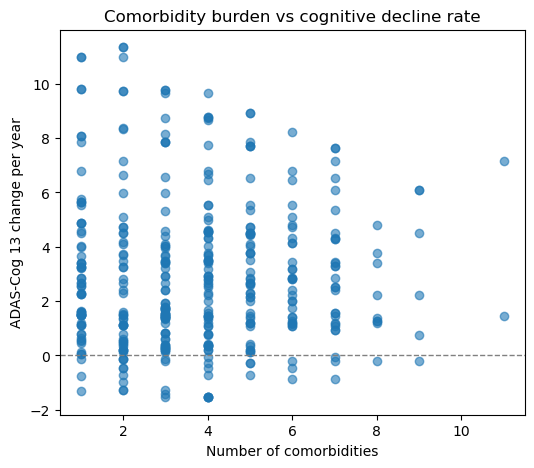

CNS Spearman ρ = 0.111, p = 0.0257
CNS Pearson r = 0.112, p = 0.0239


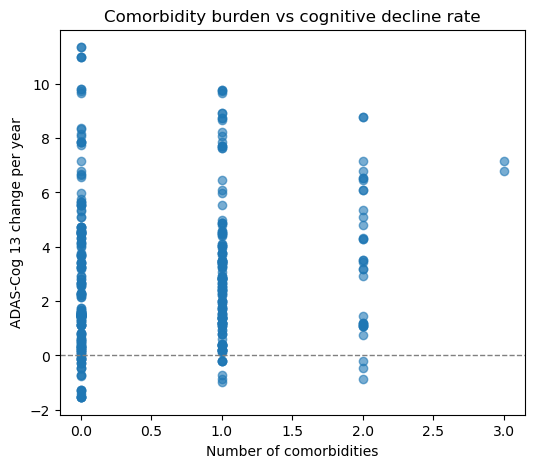

Peripheral Spearman ρ = 0.004, p = 0.9354
Peripheral Pearson r = -0.032, p = 0.5184


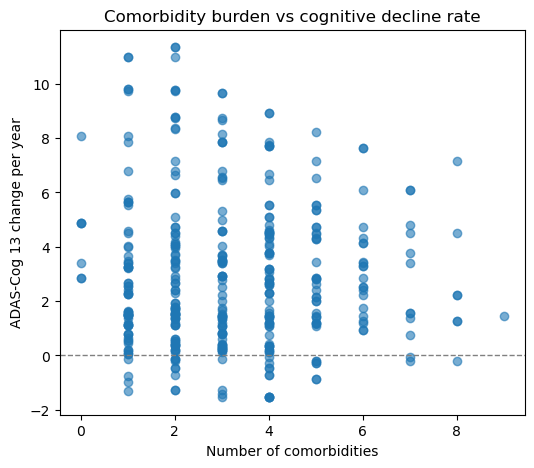

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import pearsonr

def plot_slope_by_burden(df, burden_col):
    
    rho, p = spearmanr(
        df["adas_slope_per_year"],
        df[burden_col],
        nan_policy="omit"
    )
    print(f"{burden_col} Spearman ρ = {rho:.3f}, p = {p:.4f}")

    df = df.dropna(
        subset=["adas_slope_per_year", burden_col]
    )
    r, p = pearsonr(
        df["adas_slope_per_year"],
        df[burden_col]
    )
    print(f"{burden_col} Pearson r = {r:.3f}, p = {p:.4f}")
    plt.figure(figsize=(6,5))
    plt.scatter(
        df[burden_col],
        df["adas_slope_per_year"],
        alpha=0.6
    )
    plt.xlabel("Number of comorbidities")
    plt.ylabel("ADAS-Cog 13 change per year")
    plt.title("Comorbidity burden vs cognitive decline rate")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.show()

plot_slope_by_burden(slopes, "total_conditions")
plot_slope_by_burden(slopes, "CNS")
plot_slope_by_burden(slopes, "Peripheral")

In [30]:
from scipy.stats import ttest_ind

low = slopes.loc[slopes["CNS_burden"] == "0", "adas_slope_per_year"]
high = slopes.loc[slopes["CNS_burden"] == "1+", "adas_slope_per_year"]

print(ttest_ind(low, high, equal_var=False))

low = slopes.loc[slopes["Peripheral_burden"] == "0-1", "adas_slope_per_year"]
high = slopes.loc[slopes["Peripheral_burden"] == "2+", "adas_slope_per_year"]

ttest_ind(low, high, equal_var=False)

TtestResult(statistic=np.float64(-1.5649730328630964), pvalue=np.float64(0.11837082946661125), df=np.float64(404.68724143444183))


TtestResult(statistic=np.float64(0.45099771921120735), pvalue=np.float64(0.6528775189702467), df=np.float64(110.18273590723001))

### Whole Cohort:

In [100]:
adas_dx = pd.merge(adas_df, dx_df[["RID", "VISCODE", "DIAGNOSIS"]], on=["RID", "VISCODE"], how="left")

adas_df = adas_dx.copy()
#print(adas_df[(adas_df["PTADDX"].notna()) & (adas_df["PTADDX"] != "9999.0")].head())
print(adas_df["DIAGNOSIS"].value_counts())
adas_df["time_months"] = adas_df["VISCODE"].apply(visit_to_months)
baseline_dates = (
    adas_df[adas_df["VISCODE"] == "bl"]
    .groupby("RID")["VISDATE"]
    .min()
)

adas_df_new = adas_df.merge(
    baseline_dates.rename("baseline_date"),
    on="RID",
    how="left"
)

adas_df_new["days_since_bl"] = (
    pd.to_datetime(adas_df_new["VISDATE"]) -
    pd.to_datetime(adas_df_new["baseline_date"])
)
print(adas_df_new["days_since_bl"].describe())

DIAGNOSIS
2.0    5517
1.0    4720
3.0    2607
Name: count, dtype: int64


KeyError: 'baseline_date'

In [ ]:
TARGET_DAYS = 5 * 365.25

def calculate_rate_of_decline(adas_df, target_days=TARGET_DAYS):
    baseline_whole = (
        adas_df
        .assign(abs_days=lambda d: d["days_since_bl"].abs())
        .sort_values("abs_days")
        .groupby("RID")
        .first()
        .reset_index()
        .rename(columns={
            "TOTAL13": "ADAS_bl",
            "days_since_bl": "days_bl"
        })[["RID", "ADAS_bl", "days_bl"]]
    )

    year5_whole= (
        adas_df
        .assign(abs_diff=lambda d: (d["days_since_bl"].dt.days - TARGET_DAYS).abs())
        .sort_values("abs_diff")
        .groupby("RID")
        .first()
        .reset_index()
        .rename(columns={
            "TOTAL13": "ADAS_5yr",
            "days_since_bl": "days_5yr"
        })[["RID", "ADAS_5yr", "days_5yr"]]
    )
    slopes = (
    baseline_whole
    .merge(year5_whole, on="RID", how="inner")
    )

    slopes["followup_days"] = (
        slopes["days_5yr"] - slopes["days_bl"]
    ).dt.days

    slopes["years_followup"] = slopes["followup_days"] / 365.25

    slopes["adas_slope_per_year"] = (
        (slopes["ADAS_5yr"] - slopes["ADAS_bl"]) /
        slopes["years_followup"]
    )
    slopes = slopes[
        (slopes["years_followup"] > 3) &   # ensure meaningful follow-up
        (slopes["years_followup"] < 7) &
        slopes["adas_slope_per_year"].notna()
    ]

    slopes = slopes.merge(
        comorb_wide,
        on="RID",
        how="left"
    )
    slopes[["adas_slope_per_year", "total_conditions", "CNS", "Peripheral"]].describe()

    return slopes

print(calculate_rate_of_decline(adas_df))

       RID  ADAS_bl days_bl  ADAS_5yr  days_5yr  followup_days  \
0        2    18.67  0 days     22.67 1840 days         1840.0   
1        2    18.67  0 days     22.67 1840 days         1840.0   
2        2    18.67  0 days     22.67 1840 days         1840.0   
3        4    21.33  0 days     25.00 1106 days         1106.0   
4        5    14.67  0 days     11.67 1099 days         1099.0   
...    ...      ...     ...       ...       ...            ...   
1433  7051    15.33  0 days     24.67 1167 days         1167.0   
1434  7059     2.33  0 days      6.67 1179 days         1179.0   
1435  7071    12.67  0 days     19.33 1274 days         1274.0   
1436  7074     3.00  0 days      9.00 1226 days         1226.0   
1437  7105    22.00  0 days     43.33 1112 days         1112.0   

      years_followup  adas_slope_per_year VISCODE  CNS  Peripheral  \
0           5.037645             0.794022     m60  1.0         3.0   
1           5.037645             0.794022      sc  0.0         2.0 

In [32]:
# Compare baseline ADAS-Cog across comorbidity burden groups

print(slopes.groupby("burden_category")["ADAS_bl"].agg(
    ["mean", "std", "median"]
))
print(slopes.groupby("CNS_burden")["ADAS_bl"].agg(
    ["mean", "std", "median"]
))
print(slopes.groupby("Peripheral_burden")["ADAS_bl"].agg(
    ["mean", "std", "median"]
))

                      mean       std  median
burden_category                             
High             18.283038  6.332502  18.330
Low              16.513387  7.102830  17.165
Medium           18.253137  6.666058  18.000
                 mean       std  median
CNS_burden                             
0           17.226321  6.655763    18.0
1+          18.275282  6.870838    18.0
                        mean       std  median
Peripheral_burden                             
0-1                16.926623  7.074157   17.67
2+                 17.916091  6.696385   18.00


total_conditions Spearman ρ = 0.043, p = 0.3924
total_conditions Pearson r = 0.009, p = 0.8618


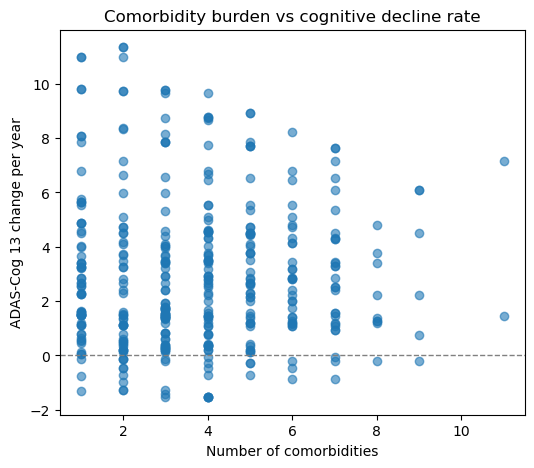

CNS Spearman ρ = 0.111, p = 0.0257
CNS Pearson r = 0.112, p = 0.0239


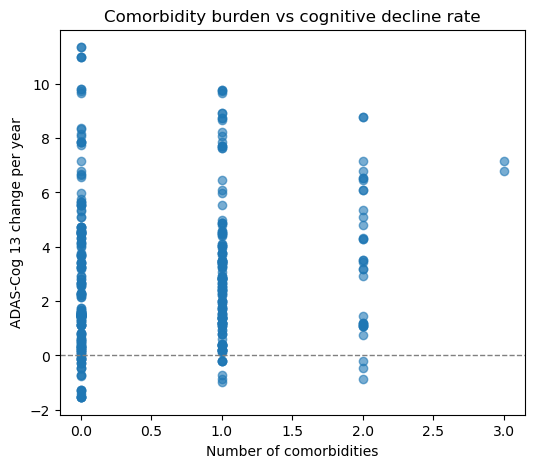

Peripheral Spearman ρ = 0.004, p = 0.9354
Peripheral Pearson r = -0.032, p = 0.5184


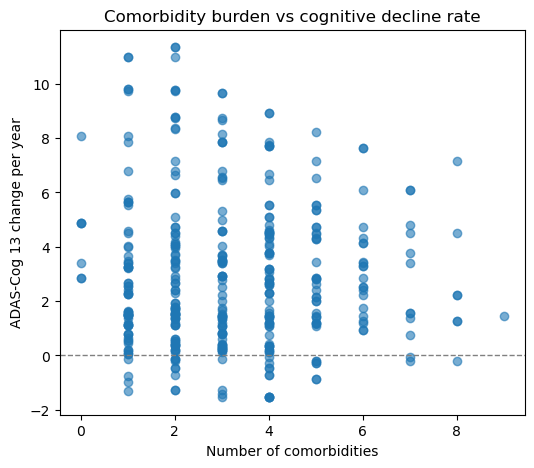

In [33]:
plot_slope_by_burden(slopes, "total_conditions")
plot_slope_by_burden(slopes, "CNS")
plot_slope_by_burden(slopes, "Peripheral")

### Identify converters to AD within the study:

In [245]:
print(adas_AD_dx["RID"].nunique())
print(adas_AD_dx.columns)

3027
Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE',
       'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2',
       'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp',
       'time_months', 'baseline_date', 'days_since_bl', 'DIAGNOSIS'],
      dtype='object')


In [246]:

adas_AD_dx['VISDATE'] = pd.to_datetime(adas_AD_dx['VISDATE'])

# Sort by subject and visit date
adas_AD_dx = adas_AD_dx.sort_values(['RID', 'VISDATE'])

df_no_bl = adas_AD_dx[adas_AD_dx['days_since_bl'].dt.days > 0].copy()

# Flag prior non-AD
df_no_bl['prev_not_AD'] = (
    df_no_bl
    .groupby('RID')['DIAGNOSIS']
    .transform(lambda x: x.shift().ne(3.0).cummax())
)

# Select rows where:
# 1) current diagnosis is 3.0
# 2) there was previously a non-3.0 diagnosis
converters_raw = df_no_bl[
    (df_no_bl['DIAGNOSIS'] == 3.0) &
    (df_no_bl['prev_not_AD'])
]


In [222]:

# Extract visit year



adas_AD_dem = adas_AD_dx.merge(
    demographics,
    on="RID",
    how="left",
    suffixes=("", "_y")
)

visit_year = adas_AD_dem["VISDATE"].dt.year

print(adas_AD_dem.columns.tolist())
# Keep rows where PTADBX or PTADDX is within 1 year of VISDATE
recent_AD_at_baseline = adas_AD_dem[
    (abs(adas_AD_dem["PTADBEG"] - visit_year) <= 1) |
    (abs(adas_AD_dem["PTADDX"] - visit_year) <= 1)
]
print(adas_AD_dem["RID"].nunique())
print(recent_AD_at_baseline["RID"].nunique())

['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE', 'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp', 'time_months', 'baseline_date', 'days_since_bl', 'DIAGNOSIS', 'PHASE_y', 'PTID_y', 'VISCODE_y', 'VISCODE2_y', 'VISDATE_y', 'PTSOURCE', 'PTGENDER', 'PTDOB', 'PTDOBYY', 'PTHAND', 'PTMARRY', 'PTEDUCAT', 'PTWORKHS', 'PTWORK', 'PTNOTRT', 'PTRTYR', 'PTHOME', 'PTTLANG', 'PTPLANG', 'PTADBEG', 'PTCOGBEG', 'PTADDX', 'PTETHCAT', 'PTRACCAT', 'PTIDENT', 'PTORIENT', 'PTORIENTOT', 'PTENGSPK', 'PTNLANG', 'PTENGSPKAGE', 'PTCLANG', 'PTLANGSP', 'PTLANGWR', 'PTSPTIM', 'PTSPOTTIM', 'PTLANGPR1', 'PTLANGSP1', 'PTLANGRD1', 'PTLANGWR1', 'PTLANGUN1', 'PTLANGPR2', 'PTLANGSP2', 'PTLANGRD2', 'PTLANGWR2', 'PTLANGUN2', 'PTLANGPR3', 'PTLANGSP3', 'PTLANGRD3', 'PTLANGWR3', 'PTLANGUN3', 'PTLANGPR4', 'PTLANGSP4', 'PTLANGRD4', 'PTLANGWR4', 'PTLANGUN4', 'PTLANGPR5', 'PTLANGSP5', 'PTLANGRD5', 'PTLANGWR5', 'PTLANGUN5', 'PTLANGPR6', 

In [223]:
converters_dem = converters_raw.merge(
    demographics[["RID", "PTDOB", 'PTGENDER', 'PTEDUCAT']],
    on="RID",
    how="left"
)
print(f"Number of converters: {converters_dem['RID'].nunique()}")



Number of converters: 563


In [ ]:

converters = converters_dem.merge(
    comorb_wide[["RID", "total_conditions", "CNS", "Peripheral", "UTI", "Z867", "Z864", "Sleep", "Dental", "CM", "CM_diabetes", "CM_afib", "CM_heart_failure", "CM_ihd", "CM_stroke"]],
    on="RID",
    how="inner")
print(f"Number of converters with comorbidity data: {converters['RID'].nunique()}")

Number of converters with comorbidity data: 430


In [186]:
recent_AD_comorb = recent_AD_at_baseline.merge(
    comorb_wide[["RID", "total_conditions", "CNS", "Peripheral", "UTI", "Z867", "Z864", "Sleep", "Dental", "CM", "CM_diabetes", "CM_afib", "CM_heart_failure", "CM_ihd", "CM_stroke"]],
    on="RID",
    how="inner")
print(f"Number of recent AD at baseline with comorbidity data: {recent_AD_comorb['RID'].nunique()}")
print(recent_AD_comorb.columns.tolist())

Number of recent AD at baseline with comorbidity data: 194
['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE', 'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp', 'time_months', 'baseline_date', 'days_since_bl', 'DIAGNOSIS', 'PHASE_y', 'PTID_y', 'VISCODE_y', 'VISCODE2_y', 'VISDATE_y', 'PTSOURCE', 'PTGENDER', 'PTDOB', 'PTDOBYY', 'PTHAND', 'PTMARRY', 'PTEDUCAT', 'PTWORKHS', 'PTWORK', 'PTNOTRT', 'PTRTYR', 'PTHOME', 'PTTLANG', 'PTPLANG', 'PTADBEG', 'PTCOGBEG', 'PTADDX', 'PTETHCAT', 'PTRACCAT', 'PTIDENT', 'PTORIENT', 'PTORIENTOT', 'PTENGSPK', 'PTNLANG', 'PTENGSPKAGE', 'PTCLANG', 'PTLANGSP', 'PTLANGWR', 'PTSPTIM', 'PTSPOTTIM', 'PTLANGPR1', 'PTLANGSP1', 'PTLANGRD1', 'PTLANGWR1', 'PTLANGUN1', 'PTLANGPR2', 'PTLANGSP2', 'PTLANGRD2', 'PTLANGWR2', 'PTLANGUN2', 'PTLANGPR3', 'PTLANGSP3', 'PTLANGRD3', 'PTLANGWR3', 'PTLANGUN3', 'PTLANGPR4', 'PTLANGSP4', 'PTLANGRD4', 'PTLANGWR4', 'PTLANGUN4', 'PTLANGPR5', 'PTLAN

In [225]:
# Keep only needed columns from first_converters

ad_start = converters[['RID', 'VISDATE', 'TOTAL13', 'PTGENDER', 'PTDOB', 'PTEDUCAT']].copy()
first_converters = (
    ad_start
    .sort_values('VISDATE')
    .groupby('RID')
    .first()
    .reset_index()
)
print(converters.columns)
first_converters['VISDATE'] = pd.to_datetime(first_converters['VISDATE'])
first_converters['PTDOB'] = pd.to_datetime(first_converters['PTDOB'])

# Calculate age at conversion (in years)
first_converters['age_at_conversion'] = (
    (first_converters['VISDATE'] - first_converters['PTDOB'])
    .dt.days / 365.25
)
first_converters['age_group'] = pd.cut(
    first_converters['age_at_conversion'],
    bins=[-np.inf, 65, 75, 80, np.inf],
    labels=[
        '<=65',
        '65-75',
        '75-80',
        '>80'
    ],
    right=True
)

ad_start = first_converters.rename(columns={
    'VISDATE': 'AD_start_date',
    'TOTAL13': 'TOTAL13_AD_start'
})

df = converters.merge(ad_start[['RID', 'AD_start_date', 'TOTAL13_AD_start',  'age_group', 'age_at_conversion']], on='RID', how='left')
print(df.head())

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE',
       'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2',
       'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp',
       'time_months', 'baseline_date', 'days_since_bl', 'DIAGNOSIS',
       'prev_not_AD', 'PTDOB', 'PTGENDER', 'PTEDUCAT', 'total_conditions',
       'CNS', 'Peripheral', 'UTI', 'Z867', 'Z864', 'Sleep', 'Dental', 'CM',
       'CM_diabetes', 'CM_afib', 'CM_heart_failure', 'CM_ihd', 'CM_stroke'],
      dtype='object')
   PHASE        PTID  RID VISCODE VISCODE2    VISDATE  TOTSCORE  TOTAL13  \
0  ADNI1  011_S_0003    3     m06      m06 2006-03-13     19.00    30.00   
1  ADNI1  011_S_0003    3     m12      m12 2006-09-12     24.00    35.00   
2  ADNI1  011_S_0003    3     m24      m24 2007-09-12     25.67    37.67   
3  ADNI1  022_S_0007    7     m06      m06 2006-04-13     32.67    45.67   
4  ADNI1  022_S_0007    7     m12      m12 2006-10-10     29.33    41.33   

        

/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/1081482572.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  first_converters['PTDOB'] = pd.to_datetime(first_converters['PTDOB'])


In [226]:
TARGET_DAYS = 1 * 365
df['VISDATE'] = pd.to_datetime(df['VISDATE'])
df['AD_start_date'] = pd.to_datetime(df['AD_start_date'])

# Keep visits AFTER AD diagnosis

df['days_since_AD'] = (df['VISDATE'] - df['AD_start_date']).dt.days
# Absolute difference from 365
df['distance_from_1yr'] = (df['days_since_AD'] - TARGET_DAYS).abs()

# For each RID, select visit closest to 1 year
one_year_visits = (
    df.sort_values(['RID', 'distance_from_1yr'])
      .groupby('RID')
      .head(1)
      .copy()
)
one_year_visits = one_year_visits[
    (one_year_visits['days_since_AD'] >= TARGET_DAYS - 180) &
    (one_year_visits['days_since_AD'] <= TARGET_DAYS + 180)
]

one_year_visits['TOTAL13_change'] = (
    one_year_visits['TOTAL13'] - 
    one_year_visits['TOTAL13_AD_start']
)

one_year_visits['annualized_decline'] = (
    one_year_visits['TOTAL13_change'] / 
    one_year_visits['days_since_AD']
) * 365.25

print(one_year_visits[['RID', 'days_since_AD', 'TOTAL13_AD_start', 'TOTAL13', 'TOTAL13_change', 'annualized_decline']].head())
print(one_year_visits['annualized_decline'].describe())


    RID  days_since_AD  TOTAL13_AD_start  TOTAL13  TOTAL13_change  \
5     7            544             45.67    47.00            1.33   
10   29            190             36.67    36.33           -0.34   
14   30            378             22.00    28.33            6.33   
29   42            386             15.00    18.33            3.33   
62   50            378             32.00    37.33            5.33   

    annualized_decline  
5             0.892983  
10           -0.653605  
14            6.116488  
29            3.150991  
62            5.150218  
count    256.000000
mean       4.861808
std        7.698807
min      -20.069322
25%        0.435972
50%        3.878230
75%        8.169988
max       38.046875
Name: annualized_decline, dtype: float64


In [189]:
df = df.merge(apoe_df[["RID", "CARRIER", "HOMO"]], on="RID", how="inner")

In [227]:
print(df.columns)
print(df["RID"].nunique())

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE',
       'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2',
       'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp',
       'time_months', 'baseline_date', 'days_since_bl', 'DIAGNOSIS',
       'prev_not_AD', 'PTDOB', 'PTGENDER', 'PTEDUCAT', 'total_conditions',
       'CNS', 'Peripheral', 'UTI', 'Z867', 'Z864', 'Sleep', 'Dental', 'CM',
       'CM_diabetes', 'CM_afib', 'CM_heart_failure', 'CM_ihd', 'CM_stroke',
       'AD_start_date', 'TOTAL13_AD_start', 'age_group', 'age_at_conversion',
       'days_since_AD', 'distance_from_1yr'],
      dtype='object')
430


In [ ]:


model_vars = [
    "TOTAL13",
    "TOTAL13_AD_start",
    "VISCODE",
    "VISDATE",
    "PHASE",
    "days_since_AD",
    "age_at_conversion",
    "PTGENDER",
    "CARRIER",
    "HOMO",
    "PTEDUCAT",
    "CNS",
    "total_conditions",
    "Peripheral",
    "RID",
    "UTI", "Z867", "Z864", "Sleep", "Dental", "CM",
    "CM_diabetes", "CM_afib", "CM_heart_failure", "CM_ihd", "CM_stroke"
]

df_no_EO = df[df['age_at_conversion'] >= 65]

df_model = df_no_EO[model_vars].dropna()
df_model["age_c"] = df_model["age_at_conversion"] - df["age_at_conversion"].mean()
df_model["edu_c"] = df_model["PTEDUCAT"] - df_model["PTEDUCAT"].mean()
df_model["time_years"] = df_model["days_since_AD"] / 365.25

print(df_model["RID"].nunique())
print(df_model.head())

400
   TOTAL13  TOTAL13_AD_start VISCODE    VISDATE  PHASE  days_since_AD  \
0    30.00             30.00     m06 2006-03-13  ADNI1              0   
1    35.00             30.00     m12 2006-09-12  ADNI1            183   
2    37.67             30.00     m24 2007-09-12  ADNI1            548   
3    45.67             45.67     m06 2006-04-13  ADNI1              0   
4    41.33             45.67     m12 2006-10-10  ADNI1            180   

   age_at_conversion  PTGENDER  CARRIER   HOMO  ...  Dental  CM  CM_diabetes  \
0          81.864476       1.0     True  False  ...     0.0   1          0.0   
1          81.864476       1.0     True  False  ...     0.0   1          0.0   
2          81.864476       1.0     True  False  ...     0.0   1          0.0   
3          76.032854       1.0     True  False  ...     0.0   1          1.0   
4          76.032854       1.0     True  False  ...     0.0   1          1.0   

   CM_afib  CM_heart_failure  CM_ihd  CM_stroke     age_c     edu_c  \
0    

In [178]:
UTIs = df_model[df_model["UTI"] == 1]
print(UTIs["RID"].nunique())
sleep = df_model[df_model["Sleep"] == 1]
print(sleep["RID"].nunique())
Z864 = df_model[df_model["Z864"] == 1]
print(Z864["RID"].nunique())
Z867 = df_model[df_model["Z867"] == 1]
print(Z867["RID"].nunique())
CM = df_model[df_model["CM"] == 1]
print(CM["RID"].nunique())
print(len(df_model))
print(sum(df_model["UTI"]))

18
71
13
42
321
4337
302.0


In [243]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "TOTAL13 ~ time_years \
     + age_c \
     + PTGENDER \
     + CARRIER \
     + edu_c \
     + CNS \
     + CM \
     + Sleep \
     + time_years:age_c \
     + time_years:PTGENDER \
     + time_years:CARRIER \
     + time_years:edu_c \
     + time_years:UTI \
     + time_years:Z867 \
     + time_years:Z864 \
     + time_years:Sleep \
     + time_years:Dental \
     + time_years:CM_diabetes \
     + time_years:CM_afib \
     + time_years:CM_heart_failure \
     + time_years:CM_ihd \
     + time_years:CM_stroke ",
    data=df_model,
    groups=df_model["RID"],
    re_formula="~time_years"
)

result = model.fit(reml=False)
print(result.summary())

                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     TOTAL13    
No. Observations:      4337        Method:                 ML         
No. Groups:            400         Scale:                  11.1490    
Min. group size:       1           Log-Likelihood:         -12446.3103
Max. group size:       180         Converged:              Yes        
Mean group size:       10.8                                           
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                   26.124    0.890 29.356 0.000 24.380 27.868
CARRIER[T.True]              1.464    0.948  1.545 0.122 -0.394  3.323
time_years                   5.238    0.592  8.853 0.000  4.078  6.397
time_years:CARRIER[T.True]   1.398    0.677  2.065 0.039  0.071  2.726
age_c                  

In [176]:
df_model["time_sq"] = df_model["time_years"] ** 2

model_quad = smf.mixedlm(
    "TOTAL13 ~ time_years + time_sq \
     + CARRIER + age_c + PTGENDER + edu_c + CNS + TOTAL13_AD_start\
     + time_years:CARRIER:total_conditions \
     + time_sq:CARRIER:total_conditions \
     + time_years:TOTAL13_AD_start \
     + time_years:CARRIER \
     + time_years:age_c \
     + time_years:PTGENDER \
     + time_years:edu_c \
     + time_sq:CARRIER \
     + time_sq:edu_c \
     + time_years:CNS",
    data=df_model,
    groups="RID",
    re_formula="~time_years"
).fit(reml=False)


print(model_quad.summary())

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          TOTAL13    
No. Observations:           4337             Method:                      ML         
No. Groups:                 400              Scale:                       10.2051    
Min. group size:            1                Log-Likelihood:              -11841.2011
Max. group size:            180              Converged:                   Yes        
Mean group size:            10.8                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  -0.044    0.486 -0.091 0.928 -0.997  0.909
CARRIER[T.True]                             0.721    0.285  2.530 0.011  0.162

In [42]:
print(result.aic, model_quad.aic)
print(result.bic, model_quad.bic)

24925.519271027435 23732.40229970072
25027.5182813288 23891.775753296602


In [43]:
print(df_model["days_since_AD"].describe())
last_visits = (
    df_model
    .sort_values(["RID", "days_since_AD"])
    .groupby("RID")
    .tail(1)
)
print(last_visits["days_since_AD"].describe())
last_days = df_model.groupby("RID")["days_since_AD"].max()
print(last_days.describe())

count    4337.000000
mean      698.298363
std       819.099756
min         0.000000
25%         0.000000
50%       396.000000
75%      1092.000000
max      6342.000000
Name: days_since_AD, dtype: float64
count     400.000000
mean      650.162500
std       666.849343
min         0.000000
25%       187.750000
50%       545.000000
75%       894.000000
max      6342.000000
Name: days_since_AD, dtype: float64
count     400.000000
mean      650.162500
std       666.849343
min         0.000000
25%       187.750000
50%       545.000000
75%       894.000000
max      6342.000000
Name: days_since_AD, dtype: float64


### Combining converters with recent AD at baseline

In [44]:
recent_AD = recent_AD_comorb.merge(apoe_df[["RID", "CARRIER", "HOMO"]], on="RID", how="inner")

recent_AD["PTADBEG"] = recent_AD["PTADBEG"].astype(str)
recent_AD["PTADDX"] = recent_AD["PTADDX"].astype(str)

# Choose PTADBEG if it starts with 1 or 2, otherwise PTADDX
recent_AD["AD_date_raw"] = np.where(
    recent_AD["PTADBEG"].str.startswith(("1", "2")),
    recent_AD["PTADBEG"],
    recent_AD["PTADDX"]
)

recent_AD["PTDOB_date"] = pd.to_datetime(
    recent_AD["PTDOB"],
    format="%m/%Y",
    errors="coerce"
)
recent_AD["AD_date"] = pd.to_datetime(
    recent_AD["AD_date_raw"].astype(float).astype("Int64").astype(str) + "-07-01",
    format="%Y-%m-%d",
    errors="coerce"
)

recent_AD['age_at_conversion'] = (
    (recent_AD['AD_date'] - recent_AD['PTDOB_date']).dt.days / 365.25
)

recent_AD['days_since_AD'] = (
    (pd.to_datetime(recent_AD['VISDATE']) - recent_AD['AD_date']).dt.days
)

recent_AD_comorb_filtered = recent_AD[[
    "TOTAL13",
    "VISDATE",
    "PHASE",
    "VISCODE",
    "days_since_AD",
    "age_at_conversion",
    "PTGENDER",
    "CARRIER",
    "HOMO",
    "PTEDUCAT",
    "total_conditions",
    "CNS",
    "RID"
]]

recent_AD_comorb_filtered = recent_AD_comorb_filtered[recent_AD_comorb_filtered['age_at_conversion'] >= 65]

recent_AD_comorb_filtered["age_c"] = recent_AD_comorb_filtered["age_at_conversion"] - recent_AD_comorb_filtered["age_at_conversion"].mean()
recent_AD_comorb_filtered["edu_c"] = recent_AD_comorb_filtered["PTEDUCAT"] - recent_AD_comorb_filtered["PTEDUCAT"].mean()
recent_AD_comorb_filtered["time_years"] = recent_AD_comorb_filtered["days_since_AD"] / 365.25

combined_data = pd.concat([df_model, recent_AD_comorb_filtered], ignore_index=True)
print(combined_data.head())

   TOTAL13  TOTAL13_AD_start VISCODE    VISDATE  PHASE  days_since_AD  \
0    30.00             30.00     m06 2006-03-13  ADNI1              0   
1    35.00             30.00     m12 2006-09-12  ADNI1            183   
2    37.67             30.00     m24 2007-09-12  ADNI1            548   
3    45.67             45.67     m06 2006-04-13  ADNI1              0   
4    41.33             45.67     m12 2006-10-10  ADNI1            180   

   age_at_conversion  PTGENDER  CARRIER   HOMO  PTEDUCAT  CNS  \
0          81.864476       1.0     True  False      18.0  1.0   
1          81.864476       1.0     True  False      18.0  1.0   
2          81.864476       1.0     True  False      18.0  1.0   
3          76.032854       1.0     True  False      10.0  1.0   
4          76.032854       1.0     True  False      10.0  1.0   

   total_conditions  Peripheral  RID     age_c     edu_c  time_years   time_sq  
0               4.0         3.0    3  4.449164  3.110445    0.000000  0.000000  
1       

In [45]:
last_days = recent_AD.groupby("RID")["days_since_AD"].max()
print(last_days.describe())

count    192.000000
mean     385.692708
std      131.904473
min      -46.000000
25%      308.750000
50%      428.000000
75%      489.500000
max      541.000000
Name: days_since_AD, dtype: float64


In [46]:
vars_used = [
    "TOTAL13", "time_years", "time_sq",
    "CARRIER", "age_c", "PTGENDER", "edu_c", "CNS",
    "RID"
]

print(combined_data[vars_used].isna().sum())
print("Rows before drop:", len(combined_data))

TOTAL13         30
time_years       0
time_sq       1240
CARRIER          0
age_c            0
PTGENDER         0
edu_c            0
CNS              0
RID              0
dtype: int64
Rows before drop: 5577


In [47]:
combined_data["time_sq"] = combined_data["time_years"] ** 2
combined_data = combined_data.dropna(subset=["TOTAL13"])
model_quad = smf.mixedlm(
    "TOTAL13 ~ time_years + time_sq \
     + CARRIER + age_c + PTGENDER + edu_c + CNS \
     + time_years:CARRIER \
     + time_years:age_c \
     + time_years:PTGENDER \
     + time_years:edu_c \
     + time_sq:CARRIER \
     + time_sq:edu_c \
     + time_years:CNS",
    data=combined_data,
    groups="RID",
    re_formula="~time_years"
).fit()


print(model_quad.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     TOTAL13    
No. Observations:     5547        Method:                 REML       
No. Groups:           473         Scale:                  12.7166    
Min. group size:      1           Log-Likelihood:         -16114.3396
Max. group size:      219         Converged:              Yes        
Mean group size:      11.7                                           
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  24.772    0.792 31.280 0.000 23.220 26.325
CARRIER[T.True]             3.435    0.889  3.863 0.000  1.692  5.178
time_years                  4.553    0.531  8.581 0.000  3.513  5.593
time_years:CARRIER[T.True]  1.167    0.615  1.898 0.058 -0.038  2.372
time_sq                     0.045   

In [48]:
print(combined_data["days_since_AD"].describe())
last_visits = (
    combined_data
    .sort_values(["RID", "days_since_AD"])
    .groupby("RID")
    .tail(1)
)
print(last_visits["days_since_AD"].describe())

count    5547.000000
mean      548.936542
std       791.823280
min      -545.000000
25%         0.000000
50%       356.000000
75%       895.000000
max      6342.000000
Name: days_since_AD, dtype: float64
count     473.000000
mean      620.033827
std       617.102290
min       -46.000000
25%       304.000000
50%       524.000000
75%       713.000000
max      6342.000000
Name: days_since_AD, dtype: float64


In [49]:
def print_demographic_summary(df):

    df = df.copy()

    # Compute age at AD start
    df["age_at_AD_start"] = (
        pd.to_datetime(df["AD_start_date"]) -
        pd.to_datetime(df["PTDOB"])
    ).dt.days / 365.25

    print(f"N = {len(df)}")

    table1 = pd.DataFrame(index=["Overall"])

    # Age
    table1.loc["Overall", "Age at diagnosis (mean ± SD)"] = (
        f"{df['age_at_AD_start'].mean():.1f} ± "
        f"{df['age_at_AD_start'].std():.1f}"
    )

    # APOE ε4 Carrier %
    table1.loc["Overall", "APOE ε4 Carrier (%)"] = (
        f"{df['CARRIER'].mean() * 100:.1f}%"
    )

    # APOE ε4 Homozygote %
    table1.loc["Overall", "APOE ε4 Homozygote (%)"] = (
        f"{df['HOMO'].mean() * 100:.1f}%"
    )

    # Education
    table1.loc["Overall", "Education (mean ± SD)"] = (
        f"{df['PTEDUCAT'].mean():.1f} ± "
        f"{df['PTEDUCAT'].std():.1f}"
    )

    print(table1.to_string())

    return table1

In [50]:
baseline_65 = print_demographic_summary(df_65)
baseline_75 = print_demographic_summary(df_75)
baseline_80 = print_demographic_summary(df_80)
baseline_80_plus = print_demographic_summary(df_80_plus)

baseline_carrier = print_demographic_summary(df_carrier)
baseline_non_carrier = print_demographic_summary(df_non_carrier)

baseline_homo = print_demographic_summary(df_homo)
baseline_non_homo = print_demographic_summary(df_non_homo)



N = 16
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   61.4 ± 2.9               50.0%                  25.0%            15.6 ± 3.5
N = 94
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   71.3 ± 2.6               81.9%                  36.2%            15.1 ± 2.8
N = 66
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   77.6 ± 1.5               71.2%                  10.6%            15.2 ± 3.2
N = 90
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   84.0 ± 3.2               48.9%                  10.0%            15.5 ± 2.7
N = 176
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   75.6 ± 6.4          

/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df["PTDOB"])
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df["PTDOB"])
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df["PTDOB"])
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer f

In [51]:
print(df_65['annualized_decline'].describe())
print(df_75['annualized_decline'].describe())
print(df_80['annualized_decline'].describe())
print(df_80_plus['annualized_decline'].describe())

print(df_carrier['annualized_decline'].describe())
print(df_non_carrier['annualized_decline'].describe())

print(df_homo['annualized_decline'].describe())
print(df_non_homo['annualized_decline'].describe())

count    16.000000
mean      4.841594
std       9.862093
min     -20.069322
25%      -0.163401
50%       2.782091
75%      12.014803
max      20.620198
Name: annualized_decline, dtype: float64
count    91.000000
mean      5.245789
std       6.887540
min      -9.317602
25%       0.901192
50%       4.519884
75%       8.528894
max      21.790483
Name: annualized_decline, dtype: float64
count    62.000000
mean      4.321652
std       7.956175
min     -13.247409
25%       0.633746
50%       3.216097
75%       7.237023
max      29.306964
Name: annualized_decline, dtype: float64
count    87.000000
mean      4.848828
std       7.992031
min      -8.702640
25%       0.126610
50%       4.013736
75%       7.509215
max      38.046875
Name: annualized_decline, dtype: float64
count    169.000000
mean       6.008568
std        7.951782
min      -12.104882
25%        1.242221
50%        5.001115
75%        9.476208
max       38.046875
Name: annualized_decline, dtype: float64
count    87.000000
mean    

In [52]:

baseline_male = print_demographic_summary(df_male)
baseline_female = print_demographic_summary(df_female)

baseline_educated = print_demographic_summary(df_educated)
baseline_less_educated = print_demographic_summary(df_less_educated)

N = 116
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   75.8 ± 7.8               65.5%                  19.0%            14.6 ± 2.8
N = 150
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   77.2 ± 6.4               66.7%                  21.3%            15.9 ± 2.8
N = 84
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   76.5 ± 7.2               59.5%                  17.9%            18.5 ± 1.0
N = 182
        Age at diagnosis (mean ± SD) APOE ε4 Carrier (%) APOE ε4 Homozygote (%) Education (mean ± SD)
Overall                   76.6 ± 7.0               69.2%                  21.4%            13.8 ± 2.2


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df["PTDOB"])
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df["PTDOB"])
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df["PTDOB"])
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/2581725539.py:8: UserWarning: Could not infer f

In [53]:
print(df_male['annualized_decline'].describe())
print(df_female['annualized_decline'].describe())

print(df_educated['annualized_decline'].describe())
print(df_less_educated['annualized_decline'].describe())

count    113.000000
mean       5.423405
std        8.355790
min      -13.247409
25%        0.522901
50%        3.672514
75%        8.454861
max       38.046875
Name: annualized_decline, dtype: float64
count    143.000000
mean       4.418028
std        7.135860
min      -20.069322
25%        0.126610
50%        3.980926
75%        8.082326
max       33.314645
Name: annualized_decline, dtype: float64
count    81.000000
mean      4.604626
std       7.500181
min     -10.006849
25%       0.000000
50%       3.619888
75%       7.426413
max      33.314645
Name: annualized_decline, dtype: float64
count    175.000000
mean       4.980846
std        7.807383
min      -20.069322
25%        0.636778
50%        4.221721
75%        8.343073
max       38.046875
Name: annualized_decline, dtype: float64


### SES investigation

In [47]:
ADI = pd.read_csv("data/ADI_17Feb2026.csv")
print(ADI.head())
print(ADI["RID"].nunique())

   PHASE        PTID   RID VISCODE VISCODE2     ADIDATE  ADISTATE ADINATIONAL  \
0  ADNI4  941_S_6254  6254  4_init      m48  2023-07-24       5.0          49   
1  ADNI4  941_S_6454  6454  4_init      m60  2023-08-11       5.0          37   
2  ADNI4  941_S_6570  6570  4_init      m60  2023-09-11       2.0          22   
3  ADNI4  941_S_6333  6333  4_init      m66  2023-09-12       1.0          12   
4  ADNI4  941_S_6058  6058  4_init      m72  2023-09-13       2.0          26   

   ADIREV   ID  SITEID    USERDATE   USERDATE2 DD_CRF_VERSION_LABEL  \
0     NaN   49     941  2023-07-26  2023-07-26                   v1   
1     NaN  115     941  2023-08-11  2023-08-11                   v1   
2     NaN  401     941  2023-09-11  2023-09-11                   v1   
3     NaN  443     941  2023-09-12  2023-09-12                   v1   
4     NaN  478     941  2023-09-13  2023-09-13                   v1   

  LANGUAGE_CODE  HAS_QC_ERROR         update_stamp  
0             e             0  20

In [48]:
# Race and Ethnicity of the cohort

print(demographics["PTRACCAT"].value_counts())
print(demographics["PTETHCAT"].value_counts())

PTRACCAT
5        4950
4         720
2         178
-4         74
7          58
6          51
1          15
1|5        15
2|5         8
4|5         6
3           4
1|4         4
2|4         3
9           2
1|4|5       2
5|8         1
3|4|5       1
5|7         1
1|7         1
8           1
Name: count, dtype: int64
PTETHCAT
 2.0    5628
 1.0     352
-4.0      76
 3.0      40
Name: count, dtype: int64


### Add CDR

In [194]:
CDR = pd.read_csv("data/CDR_19Feb2026.csv") 
print(CDR.columns)

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'CDSOURCE',
       'CDVERSION', 'SPID', 'CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN',
       'CDHOME', 'CDCARE', 'CDGLOBAL', 'CDRSB', 'ID', 'SITEID', 'USERDATE',
       'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')


### Add CSF

In [228]:
CSF = pd.read_csv("data/UPENNBIOMK_ROCHE_ELECSYS_19Feb2026.csv")
print(CSF.columns)

CSF["PTAU_ABETA42"] = CSF["PTAU"] / CSF["ABETA42"]
CSF["PT_AB_std"] = (CSF["PTAU_ABETA42"] - CSF["PTAU_ABETA42"].mean()) / CSF["PTAU_ABETA42"].std()



Index(['PHASE', 'PTID', 'RID', 'VISCODE2', 'EXAMDATE', 'BATCH', 'RUNDATE',
       'ABETA40', 'ABETA42', 'TAU', 'PTAU', 'COMMENT', 'update_stamp'],
      dtype='object')


In [229]:
CSF_bl = CSF[CSF["VISCODE2"] == "bl"]
CSF_bl["CSF_date"] = CSF_bl["EXAMDATE"]
print(CSF_bl["RID"].nunique())


1621


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/1928281327.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CSF_bl["CSF_date"] = CSF_bl["EXAMDATE"]


### Only considering converters:

In [230]:
CSF_merged = df_model.merge(
    CSF_bl[["RID", "VISCODE2", "ABETA42", "TAU", "PTAU", "PTAU_ABETA42", "PT_AB_std", "CSF_date"]],
    on=["RID"],
    how="inner")

In [ ]:

CSF_merged["time_sq"] = CSF_merged["time_years"] ** 2
CSF_merged = CSF_merged.dropna(subset=["TOTAL13"])
CSF_merged = CSF_merged.dropna(subset=["PTAU_ABETA42"])
CSF_merged["baseline_c"] = (
CSF_merged["TOTAL13_AD_start"] - CSF_merged["TOTAL13_AD_start"].mean())
print(CSF_merged["RID"].nunique())

model_quad = smf.mixedlm(
    "TOTAL13 ~ time_years + time_sq \
     + CARRIER + age_c + PTGENDER + edu_c + CNS + PT_AB_std + baseline_c\
     + CARRIER:CNS \
     + time_years:baseline_c \
     + time_sq:baseline_c \
     + time_years:CARRIER:CNS \
     + time_years:PT_AB_std:CNS \
     + time_years:CARRIER \
     + time_years:PT_AB_std \
     + time_years:age_c \
     + time_years:PTGENDER \
     + time_years:edu_c \
     + time_sq:CARRIER \
     + time_sq:edu_c \
     + time_sq:PT_AB_std \
     + time_years:CNS",
    data=CSF_merged,
    groups="RID",
    re_formula="~time_years"
).fit()


print(model_quad.summary())

214
                  Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      TOTAL13   
No. Observations:        2108         Method:                  REML      
No. Groups:              214          Scale:                   10.7878   
Min. group size:         1            Log-Likelihood:          -5841.8454
Max. group size:         72           Converged:               Yes       
Mean group size:         9.9                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      24.792    0.405 61.285 0.000 23.999 25.585
CARRIER[T.True]                 1.012    0.490  2.067 0.039  0.052  1.973
time_years                      2.926    0.836  3.498 0.000  1.287  4.565
time_years:CARRIER[T.True]      0.756    0.993  0.76

### Using larger cohort without baseline score as a feature:

In [613]:
CSF_merged_2 = combined_data.merge(
    CSF_bl[["RID", "VISCODE2", "ABETA42", "TAU", "PTAU", "PTAU_ABETA42"]],
    on=["RID"],
    how="inner")

CSF_merged_2["time_sq"] = CSF_merged_2["time_years"] ** 2
CSF_merged2 = CSF_merged_2.dropna(subset=["TOTAL13"])
CSF_merged2 = CSF_merged2.dropna(subset=["PTAU_ABETA42"])

model_quad = smf.mixedlm(
    "TOTAL13 ~ time_years + time_sq \
     + CARRIER + age_c + PTGENDER + edu_c + CNS + PTAU_ABETA42\
     + CARRIER:CNS \
     + time_years:CARRIER:CNS \
     + time_years:PTAU_ABETA42:CNS \
     + time_years:CARRIER \
     + time_years:PTAU_ABETA42 \
     + time_years:age_c \
     + time_years:PTGENDER \
     + time_years:edu_c \
     + time_sq:CARRIER \
     + time_sq:edu_c \
     + time_sq:PTAU_ABETA42 \
     + time_years:CNS",
    data=CSF_merged2,
    groups="RID",
    re_formula="~time_years"
).fit()


print(model_quad.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       TOTAL13   
No. Observations:       2635          Method:                   REML      
No. Groups:             277           Scale:                    11.6316   
Min. group size:        1             Log-Likelihood:           -7617.3971
Max. group size:        96            Converged:                Yes       
Mean group size:        9.5                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025  0.975]
--------------------------------------------------------------------------
Intercept                      21.617    1.324 16.331 0.000 19.023  24.212
CARRIER[T.True]                 1.377    1.233  1.118 0.264 -1.038   3.793
time_years                      2.171    0.904  2.403 0.016  0.400   3.942
time_years:CARRIER[T.True]      0.723    0.8

### ADAS-COG breakdown:

In [199]:
wl1_correct = ['ADAS_Q8_WL1_REC_W2_magazine', 'ADAS_Q8_WL1_REC_W3_wizard', 'ADAS_Q8_WL1_REC_W4_van',
               'ADAS_Q8_WL1_REC_W5_leopard', 'ADAS_Q8_WL1_REC_W7_sea', 'ADAS_Q8_WL1_REC_W8_train', 
               'ADAS_Q8_WL1_REC_W9_coin', 'ADAS_Q8_WL1_REC_W11_institution', 'ADAS_Q8_WL1_REC_W14_board',
               'ADAS_Q8_WL1_REC_W19_anchor', 'ADAS_Q8_WL1_REC_W20_gem', 'ADAS_Q8_WL1_REC_W22_fund',]

wl1_incorrect = ['ADAS_Q8_WL1_REC_W1_nurse', 'ADAS_Q8_WL1_REC_W6_sale', 'ADAS_Q8_WL1_REC_W10_ship',
                 'ADAS_Q8_WL1_REC_W12_map', 'ADAS_Q8_WL1_REC_W13_axe','ADAS_Q8_WL1_REC_W15_carrot', 
                 'ADAS_Q8_WL1_REC_W16_milk', 'ADAS_Q8_WL1_REC_W17_volume', 'ADAS_Q8_WL1_REC_W18_forest',
                 'ADAS_Q8_WL1_REC_W21_cat', 'ADAS_Q8_WL1_REC_W23_edge', 'ADAS_Q8_WL1_REC_W24_cake']

wl2_correct = ['ADAS_Q8_WL2_REC_W1_cost', 'ADAS_Q8_WL2_REC_W3_chimney', 'ADAS_Q8_WL2_REC_W5_damages',
               'ADAS_Q8_WL2_REC_W7_sandwich',  'ADAS_Q8_WL2_REC_W10_solution', 'ADAS_Q8_WL2_REC_W12_tube',
               'ADAS_Q8_WL2_REC_W16_engine', 'ADAS_Q8_WL2_REC_W17_riches', 'ADAS_Q8_WL2_REC_W18_gravity',
               'ADAS_Q8_WL2_REC_W22_meal', 'ADAS_Q8_WL2_REC_W23_passenger', 'ADAS_Q8_WL2_REC_W24_acid']

wl2_incorrect = ['ADAS_Q8_WL2_REC_W2_nation', 'ADAS_Q8_WL2_REC_W4_sparrow', 'ADAS_Q8_WL2_REC_W6_traffic', 
                 'ADAS_Q8_WL2_REC_W8_service', 'ADAS_Q8_WL2_REC_W9_shell', 'ADAS_Q8_WL2_REC_W11_yard', 
                 'ADAS_Q8_WL2_REC_W13_body', 'ADAS_Q8_WL2_REC_W14_ground', 'ADAS_Q8_WL2_REC_W15_stick', 
                 'ADAS_Q8_WL2_REC_W19_summer', 'ADAS_Q8_WL2_REC_W20_wisdom', 'ADAS_Q8_WL2_REC_W21_man',]

wl3_correct = ['ADAS_Q8_WL3_REC_W1_silence', 'ADAS_Q8_WL3_REC_W3_daughter', 'ADAS_Q8_WL3_REC_W6_forehead',
               'ADAS_Q8_WL3_REC_W7_tiger', 'ADAS_Q8_WL3_REC_W8_twilight', 'ADAS_Q8_WL3_REC_W12_beggar',
               'ADAS_Q8_WL3_REC_W13_echo', 'ADAS_Q8_WL3_REC_W16_village', 'ADAS_Q8_WL3_REC_W17_corner',
               'ADAS_Q8_WL3_REC_W20_courage', 'ADAS_Q8_WL3_REC_W21_bushel', 'ADAS_Q8_WL3_REC_W23_object']

wl3_incorrect = ['ADAS_Q8_WL3_REC_W2_elbow', 'ADAS_Q8_WL3_REC_W4_powder', 'ADAS_Q8_WL3_REC_W5_canal',
                 'ADAS_Q8_WL3_REC_W9_dragon', 'ADAS_Q8_WL3_REC_W10_chamber', 'ADAS_Q8_WL3_REC_W11_sister',
                 'ADAS_Q8_WL3_REC_W14_nephew', 'ADAS_Q8_WL3_REC_W15_duty', 'ADAS_Q8_WL3_REC_W18_olive',
                 'ADAS_Q8_WL3_REC_W19_music', 'ADAS_Q8_WL3_REC_W22_ribbon', 'ADAS_Q8_WL3_REC_W24_collar']

In [200]:
#adas = pd.read_csv('../Data/Raw/ADNI_ADAS_29Sep2025.csv')
adas = pd.read_csv('data/ITEM.csv')
print(adas.columns)
adas_cols = [col for col in adas.columns if col.startswith('ADAS_')]
adas = adas[adas_cols+['RID']]
adas = adas.drop(columns=['ADAS_Q1_TimeEnded', 'ADAS_QuestionnaireNotAttempted'])

## WORD RECALL ##
wls = ['WL1','WL2','WL3']
wr_titles = ['word_recall_1', 'word_recall_2', 'word_recall_3']
dr_titles = ['delayed_recall_1', 'delayed_recall_2', 'delayed_recall_3']

for i, wl in enumerate(wls):
    cols_to_sum = [col for col in adas.columns if col.startswith('ADAS_Q1_') and wl in col]
    sum_val = adas[cols_to_sum].sum(axis=1, skipna=False)
    adas[wr_titles[i]] = (30-sum_val)/3

adas['adas_word_recall'] = adas[wr_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan, 
    axis=1
)

## COMMANDS ##
commands_cols = [col for col in adas.columns if col.startswith('ADAS_Q2')]
adas['adas_commands'] = 5-(adas[commands_cols].sum(axis=1, skipna=False))

## CONSTRACTIONAL PRAXIS ##
cp_cols = [col for col in adas.columns if col.startswith('ADAS_Q3')]
adas['adas_constructional_praxis'] = 4-adas[cp_cols].sum(axis=1, skipna=False)

## DELAYED RECALL ##
for i, wl in enumerate(wls):
    cols_to_sum = [col for col in adas.columns if col.startswith('ADAS_Q4_') and wl in col]
    sum_val = adas[cols_to_sum].sum(axis=1, skipna=False)
    adas[dr_titles[i]] = 10-sum_val

adas['adas_delayed_recall'] = adas[dr_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan, 
    axis=1
)

## NAMING ##
naming_cols = [col for col in adas.columns if col.startswith('ADAS_Q5')]
adas['naming_correct'] = adas[naming_cols].sum(axis=1, skipna=False)

bins = [-1, 2, 5, 8, 11, 14, 17]
scores = [5, 4, 3, 2, 1, 0]

adas['adas_naming'] = pd.cut(adas['naming_correct'], bins=bins, labels=scores)
adas.drop(columns='naming_correct', inplace=True)

## IDEATIONAL PRAXIS ##
ip_cols = [col for col in adas.columns if col.startswith('ADAS_Q6')]
adas['adas_ideational_praxis'] = 5-adas[ip_cols].sum(axis=1, skipna=False)

## ORIENTATION ##
o_cols = [col for col in adas.columns if col.startswith('ADAS_Q7')]
adas['adas_orientation'] = 8-adas[o_cols].sum(axis=1, skipna=False)

## WORD RECOGNITION ##
correct = [wl1_correct, wl2_correct, wl3_correct]
incorrect = [wl1_incorrect, wl2_incorrect, wl3_incorrect]
wrec_titles = ['wrec_1', 'wrec_2', 'wrec_3']

for i, wl in enumerate(wls):
    correct_cols = correct[i]
    incorrect_cols = incorrect[i]
    sum_correct = 12-adas[correct_cols].sum(axis=1, skipna=False)
    sum_incorrect = adas[incorrect_cols].sum(axis=1, skipna=False)
    adas[wrec_titles[i]] = (sum_correct + sum_incorrect).clip(upper=12)

adas['adas_word_recognition'] = adas[wrec_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan,
    axis=1
)

## REMEMBERING INSTRUCTIONS, COMPREHENSIONS LANGUAGE, WORD FINDING, SPOKEN LANGUAGE ##
adas['adas_remembering_instructions'] = adas['ADAS_Q9']-1
adas['adas_comprehension_language'] = adas['ADAS_Q10']-1
adas['adas_word_finding'] = adas['ADAS_Q11']-1
adas['adas_spoken_language'] = adas['ADAS_Q12']-1

## NUMBER CANCELLATION ##
# num correctly crossed out - num errors - num of reminders
adas['adas_nc_premap'] = adas['ADAS_Q13a']-adas['ADAS_Q13b']-adas['ADAS_Q13c']
nc_bins = [-1, 4, 8, 12, 17, 22, 45]
nc_scores = [5,4,3,2,1,0]
adas['adas_number_cancellation'] = pd.cut(adas['adas_nc_premap'], bins=nc_bins, labels = nc_scores)

adas = adas[adas.columns.drop(list(adas.filter(regex='ADAS_Q1|word_recall_|ADAS_Q2|ADAS_Q3|ADAS_Q4|'
                                               'delayed_recall_|ADAS_Q5|ADAS_Q6|ADAS_Q7|_Reminder_|'
                                               'ADAS_Q9|ADAS_Q8|wrec|nc_premap')))]

adas['adas_total'] = round(adas[adas.drop(columns=['ADAS_ExamDate', 'RID']).columns].sum(axis=1, skipna=False), 2)
print(adas.columns)

Index(['RID', 'VISCODE', 'ADAS_QuestionnaireNotAttempted',
       'ADAS_Q1_T1_WL1_W1_butter', 'ADAS_Q1_T1_WL1_W2_arm',
       'ADAS_Q1_T1_WL1_W3_shore', 'ADAS_Q1_T1_WL1_W4_letter',
       'ADAS_Q1_T1_WL1_W5_queen', 'ADAS_Q1_T1_WL1_W6_cabin',
       'ADAS_Q1_T1_WL1_W7_pole',
       ...
       'TMT_PtA_Comission', 'TMT_PtA_Omission', 'TMT_PtB_Complete',
       'TMT_PtB_Comission', 'TMT_PtB_Omission', 'TMT_ExamDate',
       'WAISR_QuestionnaireNotAttempted', 'WAISR_Score', 'WAISR_ExamDate',
       'update_stamp'],
      dtype='object', length=766)
Index(['ADAS_ExamDate', 'RID', 'adas_word_recall', 'adas_commands',
       'adas_constructional_praxis', 'adas_delayed_recall', 'adas_naming',
       'adas_ideational_praxis', 'adas_orientation', 'adas_word_recognition',
       'adas_remembering_instructions', 'adas_comprehension_language',
       'adas_word_finding', 'adas_spoken_language', 'adas_number_cancellation',
       'adas_total'],
      dtype='object')


In [201]:
adas = adas.dropna()
adas['adas_number_cancellation'] = adas['adas_number_cancellation'].astype(int)
adas['adas_naming'] = adas['adas_naming'].astype(int)
adas.describe()

,RID,adas_word_recall,adas_commands,adas_constructional_praxis,adas_delayed_recall,adas_naming,adas_ideational_praxis,adas_orientation,adas_word_recognition,adas_remembering_instructions,adas_comprehension_language,adas_word_finding,adas_spoken_language,adas_number_cancellation,adas_total
count,3108.000000,3108.000000,3108.000000,3108.000000,3108.00000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000
mean,676.521557,4.557057,0.222008,0.556306,5.93565,0.286036,0.197233,1.080116,4.515122,0.156049,0.173745,0.379665,0.160875,1.072394,19.292317
std,409.772482,1.906290,0.561853,0.632544,3.04505,0.614887,0.554148,1.604132,3.296343,0.660952,0.538262,0.769551,0.532667,1.187684,11.225167
min,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,313.500000,3.333333,0.000000,0.000000,3.00000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.330000
50%,668.500000,4.666667,0.000000,0.000000,6.00000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,17.670000
75%,1028.000000,5.666667,0.000000,1.000000,9.00000,0.000000,0.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,2.000000,26.000000
max,1435.000000,10.000000,5.000000,4.000000,10.00000,5.000000,5.000000,8.000000,12.000000,5.000000,5.000000,5.000000,4.000000,5.000000,71.000000


In [202]:
"""
adas_col_map = {'adas_word_recall':'Word recall (Baseline ADAS)', 
                'adas_commands':'Commands (Baseline ADAS)',
                'adas_constructional_praxis':'Constructional praxis (Baseline ADAS)', 
                'adas_delayed_recall':'Delayed recall (Baseline ADAS)', 
                'adas_naming':'Naming (Baseline ADAS)',
                'adas_ideational_praxis':'Ideational praxis (Baseline ADAS)', 
                'adas_orientation':'Orientation (Baseline ADAS)', 
                'adas_word_recognition':'Word recognition (Baseline ADAS)',
                'adas_remembering_instructions':'Remembering instructions (Baseline ADAS)', 
                'adas_comprehension_language':'Comprehension language (Baseline ADAS)',
                'adas_word_finding':'Word finding (Baseline ADAS)', 
                'adas_spoken_language':'Spoken language (Baseline ADAS)', 
                'adas_number_cancellation':'Number cancellation (Baseline ADAS)',
                'adas_total':'Baseline ADAS-Cog'}

adas_order = ['Baseline ADAS-Cog', 'Spoken language (Baseline ADAS)',
       'Comprehension language (Baseline ADAS)',
       'Word finding (Baseline ADAS)',
       'Remembering instructions (Baseline ADAS)',
       'Word recall (Baseline ADAS)', 'Naming (Baseline ADAS)',
       'Commands (Baseline ADAS)', 'Constructional praxis (Baseline ADAS)',
       'Ideational praxis (Baseline ADAS)',
       'Orientation (Baseline ADAS)', 'Word recognition (Baseline ADAS)',
       'Number cancellation (Baseline ADAS)','Delayed recall (Baseline ADAS)', 
       ] 
       # I dropped the below rows to convert to ADASCog 11
       #'Maze (Baseline ADAS)','Number cancellation (Baseline ADAS)','Delayed recall (Baseline ADAS)', 

adas = adas.rename(columns=adas_col_map)
adas = adas[['RID','ADAS_ExamDate']+adas_order]
adas['Baseline ADAS-Cog'] = adas.loc[:, 'Spoken language (Baseline ADAS)':'Word recognition (Baseline ADAS)'].sum(axis=1) # Update if using ADAS13
adas
"""

"\nadas_col_map = {'adas_word_recall':'Word recall (Baseline ADAS)', \n                'adas_commands':'Commands (Baseline ADAS)',\n                'adas_constructional_praxis':'Constructional praxis (Baseline ADAS)', \n                'adas_delayed_recall':'Delayed recall (Baseline ADAS)', \n                'adas_naming':'Naming (Baseline ADAS)',\n                'adas_ideational_praxis':'Ideational praxis (Baseline ADAS)', \n                'adas_orientation':'Orientation (Baseline ADAS)', \n                'adas_word_recognition':'Word recognition (Baseline ADAS)',\n                'adas_remembering_instructions':'Remembering instructions (Baseline ADAS)', \n                'adas_comprehension_language':'Comprehension language (Baseline ADAS)',\n                'adas_word_finding':'Word finding (Baseline ADAS)', \n                'adas_spoken_language':'Spoken language (Baseline ADAS)', \n                'adas_number_cancellation':'Number cancellation (Baseline ADAS)',\n            

In [203]:
adas.rename(columns={'ADAS_ExamDate':'VISDATE'}, inplace=True)

adas['VISDATE'] = pd.to_datetime(adas['VISDATE'], dayfirst=True)#.dt.date
dem['VISDATE'] = pd.to_datetime(dem['VISDATE'])
print(adas.head())
print(adas.columns)
subscores_df = adas.merge(CSF_merged, how="inner")

print(subscores_df.columns)
print(subscores_df["RID"].nunique())

     VISDATE  RID  adas_word_recall  adas_commands  \
0 2005-09-08    2          3.666667            0.0   
1 2006-03-06    2          4.666667            0.0   
6 2008-08-27    2          3.000000            0.0   
7 2005-09-12    3          6.000000            1.0   
8 2006-03-13    3          5.000000            1.0   

   adas_constructional_praxis  adas_delayed_recall  adas_naming  \
0                         0.0                  5.0            0   
1                         1.0                  7.0            0   
6                         0.0                  5.0            0   
7                         1.0                  8.0            0   
8                         0.0                 10.0            0   

   adas_ideational_praxis  adas_orientation  adas_word_recognition  \
0                     0.0               0.0                    7.0   
1                     0.0               0.0                    5.0   
6                     0.0               0.0                   

In [242]:
print(adas["RID"].nunique())
print(subscores_df["RID"].nunique())
subscores_df = subscores_df.drop_duplicates(subset=["RID", "VISDATE"])
visit_counts = subscores_df.groupby("RID").size().reset_index(name="visit_count")
print(len(subscores_df))
print(visit_counts["visit_count"].value_counts())

740
141
333
visit_count
3    52
2    41
1    34
4     9
5     5
Name: count, dtype: int64


In [214]:
def print_linear_MLM_results(variable, data):
        
    model_lin = smf.mixedlm(
        f"{variable} ~ time_years\
        + CARRIER + age_c + PTGENDER + edu_c + CNS + PT_AB_std + baseline_c + CM + Sleep\
        + CARRIER:CNS \
        + time_years:baseline_c \
        + time_years:CARRIER:CNS \
        + time_years:PT_AB_std:CNS \
        + time_years:CARRIER \
        + time_years:PT_AB_std \
        + time_years:age_c \
        + time_years:PTGENDER \
        + time_years:edu_c \
        + time_years:CM \
        + time_years:Sleep",
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit()

    # Build a dataframe directly from the model object
    print(f"Impact on {variable} decline:")
    results = pd.DataFrame({
        "coef": model_lin.params,
        "pval": model_lin.pvalues
    })

    # Keep only significant predictors
    sig_results = results[results["pval"] < 0.99]

    print(sig_results)


def print_quadratic_MLM_results(variable, data):
        
    model_quad = smf.mixedlm(
        f"{variable} ~ time_years + time_sq \
        + CARRIER + age_c + PTGENDER + edu_c + CNS + PT_AB_std + baseline_c \
        + CARRIER:CNS \
        + time_years:baseline_c \
        + time_sq:baseline_c \
        + time_years:CARRIER:CNS \
        + time_years:PT_AB_std:CNS \
        + time_years:CARRIER \
        + time_years:PT_AB_std \
        + time_years:age_c \
        + time_years:PTGENDER \
        + time_years:edu_c \
        + time_sq:CARRIER \
        + time_sq:edu_c \
        + time_sq:PT_AB_std \
        + time_years:CNS",
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit()

    # Build a dataframe directly from the model object
    print(f"Impact on {variable} decline:")
    results = pd.DataFrame({
        "coef": model_quad.params,
        "pval": model_quad.pvalues
    })

    # Keep only significant predictors
    sig_results = results[results["pval"] < 0.05]

    print(sig_results)

print_linear_MLM_results("adas_total", subscores_df)
print_quadratic_MLM_results("adas_total", subscores_df)

Impact on adas_total decline:
                                    coef           pval
Intercept                      25.211269   0.000000e+00
CARRIER[T.True]                 0.096471   8.657216e-01
time_years                      1.982578   1.522850e-01
time_years:CARRIER[T.True]      2.365099   1.049374e-01
age_c                           0.052832   1.085178e-01
PTGENDER                        0.199499   3.028772e-01
edu_c                          -0.064342   1.861806e-01
CNS                             0.310579   5.651472e-01
CARRIER[T.True]:CNS            -0.167661   7.892668e-01
PT_AB_std                       0.125129   5.933861e-01
baseline_c                      0.969153  3.443684e-306
CM                             -0.077558   8.642870e-01
Sleep                          -1.102826   4.100651e-02
time_years:baseline_c           0.158335   4.068595e-02
time_years:CARRIER[False]:CNS  -0.298458   6.717090e-01
time_years:CARRIER[True]:CNS   -0.519110   4.670974e-01
time_years:PT_AB_s

In [215]:
# --- ADAS-Cog subdomain groupings ---

# Memory (5 items)
memory_items = [
    'adas_word_recall',
    'adas_delayed_recall',
    'adas_word_recognition',
    'adas_orientation',
    'adas_remembering_instructions'
]

# Language (4 items)
language_items = [
    'adas_spoken_language',
    'adas_comprehension_language',
    'adas_word_finding',
    'adas_naming'
]

# Praxis + Commands (3 items)
# Commands placed here per Verma et al. (2015) empirical factor solution
praxis_items = [
    'adas_constructional_praxis',
    'adas_ideational_praxis',
    'adas_commands'
]

# Attention (1 item) — unique to ADAS-Cog 13, no established subdomain
attention_items = [
    'adas_number_cancellation'
]

# --- Create subdomain sum scores (NaN if ANY item missing) ---
subscores_df['adas_memory']    = subscores_df[memory_items].sum(axis=1, min_count=len(memory_items))
subscores_df['adas_language']  = subscores_df[language_items].sum(axis=1, min_count=len(language_items))
subscores_df['adas_praxis']    = subscores_df[praxis_items].sum(axis=1, min_count=len(praxis_items))
subscores_df['adas_attention'] = subscores_df[attention_items].sum(axis=1, min_count=len(attention_items))

# Check how many rows have any NaN subdomain
subdomain_cols = ['adas_memory', 'adas_language', 'adas_praxis', 'adas_attention']
n_incomplete = subscores_df[subdomain_cols].isna().any(axis=1).sum()
print(f"Rows with at least one incomplete subdomain: {n_incomplete}")

# Option A: leave as NaN (keep rows, analyses can handle missing subdomains)
# — subscores_df is already in this state

# Option B: drop rows where ANY subdomain is NaN
subscores_df_complete = subscores_df.dropna(subset=subdomain_cols)
print(f"Rows retained after dropping: {len(subscores_df_complete)} / {len(subscores_df)}")

# Sanity check: subdomain scores should sum to TOTAL13
subscores_df['adas_subdomain_total'] = (
    subscores_df[['adas_memory', 'adas_language', 'adas_praxis', 'adas_attention']].sum(axis=1)
)

# Quick verification
discrepancy = (subscores_df['adas_subdomain_total'] - subscores_df['TOTAL13']).abs()
print(f"Max discrepancy vs TOTAL13: {discrepancy.max()}")
print(f"Rows with discrepancy > 0: {(discrepancy > 0.01).sum()}")

Rows with at least one incomplete subdomain: 0
Rows retained after dropping: 617 / 617
Max discrepancy vs TOTAL13: 6.00333333333333
Rows with discrepancy > 0: 98


In [216]:
subscores_df["PT_AB_std"] = (subscores_df["PTAU_ABETA42"] - subscores_df["PTAU_ABETA42"].mean()) / subscores_df["PTAU_ABETA42"].std()
#subscores_df["time_from_CSF_to_AD"] = subscores_df["CSF_date"] - subscores_df["AD_date"]

subscores_df_AD_visit = subscores_df[subscores_df["days_since_AD"] == 0]

subscores_df_AD_visit["CSF_date"] = pd.to_datetime(
    subscores_df_AD_visit["CSF_date"], errors="coerce"
)
subscores_df_AD_visit["days_from_CSF_to_AD"] = (
    subscores_df_AD_visit["CSF_date"] - subscores_df_AD_visit["VISDATE"]
).dt.days
print(subscores_df_AD_visit["days_from_CSF_to_AD"].describe())
subscores_df_new = subscores_df.merge(
    subscores_df_AD_visit[["RID", "days_from_CSF_to_AD"]],
    on="RID",
    how="left"
)
subscores_df_new.dropna(subset=["days_from_CSF_to_AD"], inplace=True)


count     238.000000
mean     -467.243697
std       306.789871
min     -1207.000000
25%      -712.000000
50%      -376.000000
75%      -182.250000
max      -119.000000
Name: days_from_CSF_to_AD, dtype: float64


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/630798557.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subscores_df_AD_visit["CSF_date"] = pd.to_datetime(
/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/630798557.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subscores_df_AD_visit["days_from_CSF_to_AD"] = (


In [217]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf

def pretty_label(var_name):
    """
    Converts snake_case variable names into publication-ready labels.
    """

    # Remove common prefixes
    prefixes = ["adas_", "cdr_", "mmse_"]
    for p in prefixes:
        if var_name.startswith(p):
            var_name = var_name[len(p):]

    # Replace underscores with spaces
    var_name = var_name.replace("_", " ")

    # Capitalize words
    var_name = var_name.title()

    return f"{var_name} Score (ADAS-Cog)" 

def quadratic_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
    {variable} ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + CNS + PT_AB_std + baseline_c + Sleep + CM
    + CARRIER:CNS
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER:CNS
    + time_years:PT_AB_std:CNS
    + time_years:CARRIER
    + time_years:PT_AB_std
    + time_years:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:CARRIER
    + time_sq:edu_c
    + time_sq:PT_AB_std
    + time_years:CNS
    + time_years:Peripheral
    + time_years:Sleep
    + time_years:CM
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.05]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"quadratic_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 3, "Low"),
        (0.5, "-",  3, "Median"),
        (0.9, "--", 3, "High")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)
       
        if q == 0.5:
            ref_color = "#1b9e77"
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"quadratic_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def linear_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
        {variable} ~ time_years
        + CARRIER + age_c + PTGENDER + edu_c + CNS + Peripheral + PT_AB_std + baseline_c + Sleep + CM
        + time_years:baseline_c 
        + time_years:CARRIER 
        + time_years:PT_AB_std 
        + time_years:days_from_CSF_to_AD
        + time_years:age_c 
        + time_years:PTGENDER 
        + time_years:edu_c 
        + time_years:CNS
        + time_years:Peripheral
        + time_years:Sleep
        + time_years:CM
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 2]
    #sig_results = results[results["pval"] < 0.05]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"linear_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 3, "Low (P10)"),
        (0.5, "-",  3, "Median"),
        (0.9, "--", 3, "High (P90)")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)

       
        if q == 0.5:
            ref_color = "#1b9e77"  
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"linear_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def compare_lin_quad(variable, data):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"linear_{variable}"
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"quadratic_{variable}"
    )
    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")

compare_lin_quad("TOTAL13",subscores_df_new)
compare_lin_quad("adas_total",subscores_df_new)
compare_lin_quad("adas_memory",subscores_df_new)
compare_lin_quad("adas_language",subscores_df_new)
compare_lin_quad("adas_praxis",subscores_df_new)
compare_lin_quad("adas_attention",subscores_df_new)



Significant predictors for TOTAL13:
                                     coef          pval
Intercept                       25.463375  0.000000e+00
CARRIER[T.True]                  0.117628  7.742412e-01
time_years                       0.690213  6.866435e-01
time_years:CARRIER[T.True]       2.403956  1.073564e-01
age_c                            0.048860  8.896250e-02
PTGENDER                         0.133416  3.818211e-01
edu_c                           -0.043469  2.532371e-01
CNS                              0.166804  3.495509e-01
Peripheral                      -0.058501  4.685237e-01
PT_AB_std                        0.097816  5.583174e-01
baseline_c                       0.969631  0.000000e+00
Sleep                           -0.516378  1.135037e-01
CM                               0.033807  8.896777e-01
time_years:baseline_c            0.249960  3.749499e-03
time_years:PT_AB_std             1.435085  2.377443e-02
time_years:days_from_CSF_to_AD  -0.005852  8.827342e-02
time_years:

In [219]:
print(len(subscores_df_new))
print(subscores_df_new["RID"].nunique())

2371
131


In [ ]:
'Baseline ADAS-Cog',
       'Spoken language (Baseline ADAS)',
       'Comprehension language (Baseline ADAS)',
       'Word finding (Baseline ADAS)',
       'Remembering instructions (Baseline ADAS)',
       'Word recall (Baseline ADAS)', 'Naming (Baseline ADAS)',
       'Commands (Baseline ADAS)', 'Constructional praxis (Baseline ADAS)',
       'Ideational praxis (Baseline ADAS)', 'Orientation (Baseline ADAS)',
       'Word recognition (Baseline ADAS)',
       'Number cancellation (Baseline ADAS)', 'Delayed recall (Baseline ADAS)',

### CDR subdomains:

In [472]:
CDR_CSF = CSF_merged.merge(CDR, on=["RID", "VISCODE"], how="inner")
"""
print_quadratic_MLM_results("CDMEMORY", CDR_CSF)
print_quadratic_MLM_results("CDORIENT", CDR_CSF)
print_quadratic_MLM_results("CDJUDGE", CDR_CSF)
print_quadratic_MLM_results("CDCOMMUN", CDR_CSF)
print_quadratic_MLM_results("CDHOME", CDR_CSF)
print_quadratic_MLM_results("CDCARE", CDR_CSF)
print_quadratic_MLM_results("CDGLOBAL", CDR_CSF)
"""

'\nprint_quadratic_MLM_results("CDMEMORY", CDR_CSF)\nprint_quadratic_MLM_results("CDORIENT", CDR_CSF)\nprint_quadratic_MLM_results("CDJUDGE", CDR_CSF)\nprint_quadratic_MLM_results("CDCOMMUN", CDR_CSF)\nprint_quadratic_MLM_results("CDHOME", CDR_CSF)\nprint_quadratic_MLM_results("CDCARE", CDR_CSF)\nprint_quadratic_MLM_results("CDGLOBAL", CDR_CSF)\n'

In [478]:
cdr_cols = [col for col in CDR_CSF.columns if col.startswith("CD")]

CDR_CSF_clean = CDR_CSF[~(CDR_CSF[cdr_cols] == -1.0).any(axis=1)]

In [479]:
CDR_CSF_clean["CDCARE"].value_counts()

CDCARE
0.0    1233
1.0     625
2.0     165
3.0      59
Name: count, dtype: int64

In [480]:

compare_lin_quad("CDMEMORY",CDR_CSF_clean)
compare_lin_quad("CDORIENT",CDR_CSF_clean)
compare_lin_quad("CDJUDGE",CDR_CSF_clean)
compare_lin_quad("CDCOMMUN",CDR_CSF_clean)
compare_lin_quad("CDHOME",CDR_CSF_clean)
compare_lin_quad("CDCARE",CDR_CSF_clean)
compare_lin_quad("CDGLOBAL",CDR_CSF_clean)
compare_lin_quad("CDRSB",CDR_CSF_clean)


Significant predictors for CDMEMORY:
                          coef          pval
Intercept             0.962298  5.798054e-67
time_years            0.131001  5.401732e-03
age_c                 0.010129  1.707333e-02
baseline_c            0.022497  2.141684e-15
RID Var               1.597289  1.089773e-14
RID x time_years Cov -0.349545  1.028932e-02
time_years Var        0.836051  2.292977e-07

Saved files:
 → linear_CDMEMORY_CDMEMORY_trajectories.png
 → linear_CDMEMORY_CDMEMORY_significant_results.csv

Significant predictors for CDMEMORY:
                                coef          pval
Intercept                   0.973363  2.803142e-68
time_years                  0.103213  3.410892e-02
time_years:CARRIER[T.True]  0.125694  2.454757e-02
time_sq                     0.009058  4.804366e-02
age_c                       0.009723  2.202893e-02
baseline_c                  0.022014  9.827575e-15
RID Var                     1.606354  1.250638e-14
RID x time_years Cov       -0.355300  1.03320

### Exploring Logisitic / Gompertz regression

In [348]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def fit_linear(variable, data):
    model = smf.mixedlm(
        f"{variable} ~ time_years + baseline_c",
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)
    return model

def fit_quadratic(variable, data):
    data["time_sq"] = data["time_years"]**2

    model = smf.mixedlm(
        f"{variable} ~ time_years + time_sq + baseline_c \
           + time_years:baseline_c + time_sq:baseline_c",
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)
    return model

def logistic_function(t, L, U, k, t0):
    return L + (U - L) / (1 + np.exp(k * (t - t0)))

def logistic_nll(params, data, y, t, group_ids):
    L, U, k, t0, sigma = params[:5]
    b = params[5:]  # one random intercept per subject
    
    unique_ids = np.unique(group_ids)
    pred = np.zeros_like(y)
    
    for i, rid in enumerate(unique_ids):
        mask = group_ids == rid
        pred[mask] = logistic_function(t[mask], L, U, k, t0) + b[i]
    
    ll = -0.5 * np.sum((y - pred)**2 / sigma**2 + np.log(2*np.pi*sigma**2))
    
    return -ll  

def gompertz_function(t, L, U, k, t0):
    return L + (U - L) * np.exp(-np.exp(k * (t - t0)))

def gompertz_nll(params, data, y, t, group_ids):
    L, U, k, t0, sigma = params[:5]
    b = params[5:]
    
    unique_ids = np.unique(group_ids)
    pred = np.zeros_like(y)
    
    for i, rid in enumerate(unique_ids):
        mask = group_ids == rid
        pred[mask] = gompertz_function(t[mask], L, U, k, t0) + b[i]
    
    ll = -0.5 * np.sum((y - pred)**2 / sigma**2 + np.log(2*np.pi*sigma**2))
    
    return -ll

In [349]:
def fit_logistic(variable, data):
    
    y = data[variable].values
    t = data["time_years"].values
    group_ids = data["RID"].values
    
    unique_ids = np.unique(group_ids)
    n_subjects = len(unique_ids)
    
    # Initial guesses
    init_params = np.concatenate([
        [y.min(), y.max(), 0.5, np.median(t), 1.0],  # L, U, k, t0, sigma
        np.zeros(n_subjects)  # random intercepts
    ])
    
    result = minimize(
        logistic_nll,
        init_params,
        args=(data, y, t, group_ids),
        method="L-BFGS-B"
    )
    
    loglik = -result.fun
    k_params = len(result.x)
    n = len(y)
    
    bic = -2*loglik + k_params * np.log(n)
    
    return {"result": result, "BIC": bic}

def fit_gompertz(variable, data):
    
    y = data[variable].values
    t = data["time_years"].values
    group_ids = data["RID"].values
    
    unique_ids = np.unique(group_ids)
    n_subjects = len(unique_ids)
    
    init_params = np.concatenate([
        [y.min(), y.max(), 0.5, np.median(t), 1.0],
        np.zeros(n_subjects)
    ])
    
    result = minimize(
        gompertz_nll,
        init_params,
        args=(data, y, t, group_ids),
        method="L-BFGS-B"
    )
    
    loglik = -result.fun
    k_params = len(result.x)
    n = len(y)
    
    bic = -2*loglik + k_params * np.log(n)
    
    return {"result": result, "BIC": bic}

In [350]:
def compare_models(variable, data):
    
    lin = fit_linear(variable, data)
    quad = fit_quadratic(variable, data)
    logi = fit_logistic(variable, data)
    gomp = fit_gompertz(variable, data)
    
    results = pd.DataFrame({
        "Model": ["Linear", "Quadratic", "Logistic", "Gompertz"],
        "BIC": [
            lin.bic,
            quad.bic,
            logi["BIC"],
            gomp["BIC"]
        ]
    })
    
    print(results.sort_values("BIC"))

In [351]:
print(compare_models("TOTAL13", CDR_CSF))

       Model           BIC
1  Quadratic  11748.995665
0     Linear  11922.686721
3   Gompertz  15283.333849
2   Logistic  17567.129838
None


### Exploring functional decline:

In [375]:
FAQ = pd.read_csv('data/FAQ_24Feb2026.csv')
FAQ = FAQ.dropna(subset=['FAQTOTAL'])

In [482]:
df_FAQ = CSF_merged.merge(FAQ[["RID", "VISCODE", "FAQTOTAL"]], on=["RID", "VISCODE"], how="inner")
print(df_FAQ["RID"].nunique())


213


In [378]:
print(print_linear_MLM_results("FAQTOTAL", df_FAQ))
print(print_quadratic_MLM_results("FAQTOTAL", df_FAQ))

Impact on FAQTOTAL decline:
                           coef          pval
Intercept             12.646067  1.002836e-29
time_years             2.227331  2.948782e-03
baseline_c             0.311622  5.760724e-10
RID Var                6.999852  6.979246e-19
RID x time_years Cov  -1.127524  1.855278e-03
time_years Var         1.955362  7.287382e-10
None
Impact on FAQTOTAL decline:
                           coef          pval
Intercept             12.621803  1.466181e-29
time_years             2.420730  1.475748e-03
baseline_c             0.309730  7.758287e-10
time_sq:PTAU_ABETA42   2.383582  1.300773e-02
RID Var                7.055672  6.765607e-19
RID x time_years Cov  -1.140540  1.790979e-03
time_years Var         1.976365  6.866691e-10
None


In [483]:
print(compare_lin_quad("FAQTOTAL", df_FAQ))


Significant predictors for FAQTOTAL:
                           coef          pval
Intercept             12.363527  2.375112e-43
time_years             2.916035  4.702368e-07
baseline_c             0.311532  3.275335e-10
RID Var                6.815356  3.318406e-19
RID x time_years Cov  -1.079860  1.819666e-03
time_years Var         1.861002  6.215204e-10

Saved files:
 → linear_FAQTOTAL_FAQTOTAL_trajectories.png
 → linear_FAQTOTAL_FAQTOTAL_significant_results.csv

Significant predictors for FAQTOTAL:
                           coef          pval
Intercept             12.394899  1.699429e-43
time_years             2.904690  7.644577e-07
baseline_c             0.309652  4.442558e-10
time_sq:PT_AB_std      0.078341  1.291951e-02
RID Var                6.890720  3.129340e-19
RID x time_years Cov  -1.095753  1.750574e-03
time_years Var         1.887494  5.743010e-10

Saved files:
 → quadratic_FAQTOTAL_FAQTOTAL_trajectories.png
 → quadratic_FAQTOTAL_FAQTOTAL_significant_results.csv
BIC Li

### Add in Hamilton Oh's protein ratio:

In [397]:
YWHAG = pd.read_csv('data/CSF_SOMAscan.csv')
YWHAG.columns

Index(['RID', 'EXAMDATE', 'GUSPECID', 'Somalogic_Barcode_A', 'VISCODE2',
       'ExtIdentifier', 'PlateId', 'X10000.28', 'X10001.7', 'X10003.15',
       ...
       'X9984.12', 'X9986.14', 'X9987.30', 'X9989.12', 'X9991.112', 'X9993.11',
       'X9994.217', 'X9995.6', 'X9997.12', 'X9999.1'],
      dtype='object', length=7015)

In [399]:
YWHAG_info = pd.read_csv('data/CSF_SOMAscan_information.csv')
YWHAG_info.columns

Index(['Analytes', 'SeqId', 'SeqIdVersion', 'SomaId', 'TargetFullName',
       'Target', 'UniProt', 'EntrezGeneID', 'EntrezGeneSymbol', 'Organism',
       'Units', 'Type', 'Dilution', 'NormGroup'],
      dtype='object')

In [400]:
# Mapping from SOMAmer ID (column name in WHAG) to gene symbol
probe_to_gene = dict(zip(YWHAG_info['Analytes'], YWHAG_info['EntrezGeneSymbol']))

# Find probes for the genes of interest
genes_of_interest = ['YWHAG', 'NPTX2']

# Filter mapping for only these genes
probes_of_interest = {k: v for k, v in probe_to_gene.items() if v in genes_of_interest}

print(probes_of_interest)

{'X4179.57': 'YWHAG', 'X6521.35': 'NPTX2', 'X8901.40': 'YWHAG'}


In [418]:
# Select only the columns for YWHAG and NPTX2 plus identifiers
columns_to_use = ['RID', 'EXAMDATE'] + list(probes_of_interest.keys())
subset_df = YWHAG[columns_to_use]

# Rename columns to gene symbols for clarity
subset_df = subset_df.rename(columns=probes_of_interest)
genes = ['YWHAG', 'NPTX2']
for gene in genes:
    probes = [col for col in subset_df.columns if col.endswith(gene)]
    subset_df[gene + '_mean'] = subset_df[probes].mean(axis=1)
# Assuming both are numeric
subset_df['YWHAG_NPTX2_ratio'] = subset_df['YWHAG_mean'] / subset_df['NPTX2_mean']

# View the first few rows
print(subset_df.head())

    RID   EXAMDATE   YWHAG    NPTX2   YWHAG  YWHAG_mean  NPTX2_mean  \
0  4521   3/2/2012  5102.0  15463.0  4493.4     4797.70     15463.0   
1  4488  2/23/2012  2211.5  13129.7  2486.6     2349.05     13129.7   
2  4516  2/28/2012  2081.2  17315.4  2718.7     2399.95     17315.4   
3  4530  2/22/2012  3263.3   7126.8  2719.0     2991.15      7126.8   
4  4462  2/28/2012  3006.5  11181.7  3120.3     3063.40     11181.7   

   YWHAG_NPTX2_ratio  
0           0.310270  
1           0.178911  
2           0.138602  
3           0.419704  
4           0.273965  


In [425]:
print(subset_df["RID"].nunique())
print(len(subset_df))

735
737


In [488]:
subset_df['EXAMDATE'] = pd.to_datetime(subset_df['EXAMDATE'])
YWAG_ADAS = subset_df.merge(adas_AD_dx[["RID", "VISDATE", "TOTAL13"]], left_on=["RID", "EXAMDATE"], right_on=["RID", "VISDATE"], how="inner")
print(YWAG_ADAS["RID"].nunique())

209


In [ ]:
subset_df['EXAMDATE'] = pd.to_datetime(subset_df['EXAMDATE'])
CSF_new = CSF_merged.merge(subset_df[['RID', 'EXAMDATE', 'YWHAG_mean', 'NPTX2_mean', 'YWHAG_NPTX2_ratio']],
                          left_on=['RID'], right_on=['RID'], how='inner')
CSF_new = CSF_new[CSF_new[]]
print(CSF_new["RID"].nunique())
print(CSF_new.columns)


157
Index(['TOTAL13', 'TOTAL13_AD_start', 'VISCODE', 'VISDATE', 'PHASE',
       'days_since_AD', 'age_at_conversion', 'PTGENDER', 'CARRIER', 'HOMO',
       'PTEDUCAT', 'CNS', 'total_conditions', 'RID', 'age_c', 'edu_c',
       'time_years', 'time_sq', 'VISCODE2', 'ABETA42', 'TAU', 'PTAU',
       'PTAU_ABETA42', 'PT_AB_std', 'baseline_c', 'EXAMDATE', 'YWHAG_mean',
       'NPTX2_mean', 'YWHAG_NPTX2_ratio'],
      dtype='object')
VISCODE2
bl    1457
Name: count, dtype: int64


In [424]:
# Get baseline VISDATE per participant

first_converters = (
    CSF_new
    .sort_values('VISDATE')
    .groupby('RID')
    .first()
    .reset_index()
)
baseline = first_converters[['RID', 'VISDATE']].rename(columns={'VISDATE': 'baseline_VISDATE'})

# Merge baseline back
CSF_w_bl = CSF_new.merge(baseline, on='RID', how='left')

# Calculate days since baseline for EXAMDATE (proteinomics)
CSF_w_bl['days_since_baseline_protein'] = (CSF_w_bl['EXAMDATE'] - CSF_w_bl['baseline_VISDATE']).dt.days

# Also calculate days since baseline for cognitive visit (optional, likely already have it)
CSF_w_bl['days_since_baseline_cog'] = (CSF_w_bl['VISDATE'] - CSF_w_bl['baseline_VISDATE']).dt.days

print(CSF_w_bl['days_since_baseline_protein'].describe())

count    1457.000000
mean     -992.372684
std      1613.401794
min     -4753.000000
25%     -1843.000000
50%      -560.000000
75%      -176.000000
max      1654.000000
Name: days_since_baseline_protein, dtype: float64


In [407]:
import pandas as pd
import numpy as np

# Convert to datetime if not already
CSF_merged['VISDATE'] = pd.to_datetime(CSF_merged['VISDATE'])
subset_df['EXAMDATE'] = pd.to_datetime(subset_df['EXAMDATE'])

# Merge by RID first
merged = CSF_merged.merge(subset_df, on='RID', suffixes=('_CSF', '_prot'))

# Keep only rows where dates are within 30 days
merged['date_diff'] = (merged['EXAMDATE'] - merged['VISDATE']).abs().dt.days
merged_window = merged[merged['date_diff'] <= 30]

print(f"Rows within 30 days window: {merged_window.shape[0]}")

Rows within 30 days window: 36


In [495]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf

def pretty_label(var_name):
    """
    Converts snake_case variable names into publication-ready labels.
    """

    # Remove common prefixes
    prefixes = ["adas_", "cdr_", "mmse_"]
    for p in prefixes:
        if var_name.startswith(p):
            var_name = var_name[len(p):]

    # Replace underscores with spaces
    var_name = var_name.replace("_", " ")

    # Capitalize words
    var_name = var_name.title()

    return f"{var_name} Score (ADAS-Cog)" 

def quadratic_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
    {variable} ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + CNS + PT_AB_std + baseline_c + YWHAG_NPTX2_ratio
    + CARRIER:CNS
    + time_years:YWHAG_NPTX2_ratio
    + time_sq:YWHAG_NPTX2_ratio
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER:CNS
    + time_years:PT_AB_std:CNS
    + time_years:CARRIER
    + time_years:PT_AB_std
    + time_years:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:CARRIER
    + time_sq:edu_c
    + time_sq:PT_AB_std
    + time_years:CNS
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.05]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"quadratic_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 3, "Low"),
        (0.5, "-",  3, "Median"),
        (0.9, "--", 3, "High")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)
       
        if q == 0.5:
            ref_color = "#1b9e77"
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"quadratic_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def linear_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
        {variable} ~ time_years
        + CARRIER + age_c + PTGENDER + edu_c + CNS + PT_AB_std + baseline_c + YWHAG_NPTX2_ratio
        + CARRIER:CNS 
        + time_years:YWHAG_NPTX2_ratio
        + time_years:baseline_c 
        + time_years:CARRIER:CNS 
        + time_years:PT_AB_std:CNS 
        + time_years:CARRIER 
        + time_years:PT_AB_std 
        + time_years:age_c 
        + time_years:PTGENDER 
        + time_years:edu_c 
        + time_years:CNS
        """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.5]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"linear_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 3, "Low (P10)"),
        (0.5, "-",  3, "Median"),
        (0.9, "--", 3, "High (P90)")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)

       
        if q == 0.5:
            ref_color = "#1b9e77"  
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"linear_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def compare_lin_quad(variable, data):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"linear_{variable}"
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"quadratic_{variable}"
    )
    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")


In [497]:
CSF_new["YWHAG_NPTX2_ratio"] = (CSF_new["YWHAG_NPTX2_ratio"] - CSF_new["YWHAG_NPTX2_ratio"].mean()) / CSF_new["YWHAG_NPTX2_ratio"].std()

CSF_new = CSF_new.dropna(subset=["YWHAG_NPTX2_ratio"])
print(compare_lin_quad("TOTAL13", CSF_new))


Significant predictors for TOTAL13:
                                   coef          pval
Intercept                     24.762081  0.000000e+00
CARRIER[T.True]                1.115513  8.192412e-02
time_years                     4.579739  2.576278e-07
age_c                          0.047338  1.945471e-01
PTGENDER                      -0.266677  2.673004e-01
edu_c                          0.051277  3.997734e-01
CNS                            0.486260  4.878675e-01
CARRIER[T.True]:CNS           -0.661780  4.239190e-01
baseline_c                     0.981694  0.000000e+00
time_years:YWHAG_NPTX2_ratio   0.618127  1.527908e-01
time_years:baseline_c          0.080699  1.071338e-01
time_years:CNS                -0.280971  4.824451e-01
time_years:PT_AB_std           0.987386  6.058081e-02
time_years:age_c              -0.218438  2.110211e-03
time_years:PTGENDER           -0.356545  3.171123e-01
time_years:edu_c               0.111804  2.377813e-01
RID Var                        0.188751  1.60

### Using study entry as baseline

In [248]:
AD_dem = adas_AD_dx.merge(
    demographics[["RID", "PTDOB", 'PTGENDER', 'PTEDUCAT']],
    on="RID",
    how="left"
)
print(f"Number of converters: {AD_dem['RID'].nunique()}")


AD = AD_dem.merge(
    comorb_wide[["RID", "total_conditions", "CNS", "Peripheral", "UTI", "Z867", "Z864", "Sleep", "Dental", "CM", "CM_diabetes", "CM_afib", "CM_heart_failure", "CM_ihd", "CM_stroke"]],
    on="RID",
    how="inner")
print(f"Number of converters with comorbidity data: {AD['RID'].nunique()}")

Number of converters: 3027
Number of converters with comorbidity data: 1681


In [252]:
ad_start = AD[['RID', 'VISDATE', 'TOTAL13', 'PTGENDER', 'PTDOB', 'PTEDUCAT']].copy()
first_entries = (
    ad_start
    .sort_values('VISDATE')
    .groupby('RID')
    .first()
    .reset_index()
)

first_entries['VISDATE'] = pd.to_datetime(first_entries['VISDATE'])
first_entries['PTDOB'] = pd.to_datetime(first_entries['PTDOB'])

# Calculate age at conversion (in years)
first_entries['age_at_conversion'] = (
    (first_entries['VISDATE'] - first_entries['PTDOB'])
    .dt.days / 365.25
)
first_entries['age_group'] = pd.cut(
    first_entries['age_at_conversion'],
    bins=[-np.inf, 65, 75, 80, np.inf],
    labels=[
        '<=65',
        '65-75',
        '75-80',
        '>80'
    ],
    right=True
)

ad_start = first_entries.rename(columns={
    'VISDATE': 'AD_start_date',
    'TOTAL13': 'TOTAL13_AD_start'
})

AD_new = AD.merge(ad_start[['RID', 'AD_start_date', 'TOTAL13_AD_start',  'age_group', 'age_at_conversion']], on='RID', how='left')
print(df.head())

   PHASE        PTID  RID VISCODE VISCODE2    VISDATE  TOTSCORE  TOTAL13  \
0  ADNI1  011_S_0002    2      bl       bl 2005-09-08     10.67    18.67   
1  ADNI1  011_S_0002    2      bl       bl 2005-09-08     10.67    18.67   
2  ADNI1  011_S_0002    2      bl       bl 2005-09-08     10.67    18.67   
3  ADNI1  011_S_0002    2      bl       bl 2005-09-08     10.67    18.67   
4  ADNI1  011_S_0002    2      bl       bl 2005-09-08     10.67    18.67   

         ID  SITEID  ... CM CM_diabetes CM_afib CM_heart_failure  CM_ihd  \
0  16492479     107  ...  1         1.0     0.0              0.0     1.0   
1  16492479     107  ...  1         1.0     0.0              0.0     0.0   
2  16492479     107  ...  1         1.0     0.0              0.0     1.0   
3  16492479     107  ...  1         1.0     0.0              0.0     1.0   
4  16492479     107  ...  1         1.0     0.0              0.0     0.0   

  CM_stroke  AD_start_date TOTAL13_AD_start age_group  age_at_conversion  
0       0.0

/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_29117/4126688567.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  first_entries['PTDOB'] = pd.to_datetime(first_entries['PTDOB'])


In [254]:
AD_df = AD_new.merge(apoe_df[["RID", "CARRIER", "HOMO"]], on="RID", how="inner")

AD_df['VISDATE'] = pd.to_datetime(AD_df['VISDATE'])
AD_df['AD_start_date'] = pd.to_datetime(AD_df['AD_start_date'])
AD_df['days_since_AD'] = (AD_df['VISDATE'] - AD_df['AD_start_date']).dt.days

AD_no_EO = AD_df[AD_df['age_at_conversion'] >= 65]

AD_model = AD_no_EO[model_vars].dropna()
AD_model["age_c"] = AD_model["age_at_conversion"] - AD_no_EO["age_at_conversion"].mean()
AD_model["edu_c"] = AD_model["PTEDUCAT"] - AD_no_EO["PTEDUCAT"].mean()
AD_model["time_years"] = AD_model["days_since_AD"] / 365.25

print(AD_model["RID"].nunique())
print(AD_model.head())

1476
   TOTAL13  TOTAL13_AD_start VISCODE    VISDATE  PHASE  days_since_AD  \
0    18.67             18.67      bl 2005-09-08  ADNI1            0.0   
1    18.67             18.67      bl 2005-09-08  ADNI1            0.0   
2    18.67             18.67      bl 2005-09-08  ADNI1            0.0   
3    18.67             18.67      bl 2005-09-08  ADNI1            0.0   
4    18.67             18.67      bl 2005-09-08  ADNI1            0.0   

   age_at_conversion  PTGENDER  CARRIER   HOMO  ...  Dental  CM  CM_diabetes  \
0          74.439425       1.0    False  False  ...     0.0   1          1.0   
1          74.439425       1.0    False  False  ...     0.0   1          1.0   
2          74.439425       1.0    False  False  ...     0.0   1          1.0   
3          74.439425       1.0    False  False  ...     0.0   1          1.0   
4          74.439425       1.0    False  False  ...     0.0   1          1.0   

   CM_afib  CM_heart_failure  CM_ihd  CM_stroke     age_c     edu_c  \
0   

In [256]:
CSF_AD = AD_model.merge(
    CSF_bl[["RID", "VISCODE2", "ABETA42", "TAU", "PTAU", "PTAU_ABETA42", "PT_AB_std", "CSF_date"]],
    on=["RID"],
    how="inner")
CSF_AD["time_sq"] = CSF_AD["time_years"] ** 2
CSF_AD = CSF_AD.dropna(subset=["TOTAL13"])
CSF_AD = CSF_AD.dropna(subset=["PTAU_ABETA42"])
CSF_AD["baseline_c"] = (
CSF_AD["TOTAL13_AD_start"] - CSF_AD["TOTAL13_AD_start"].mean())
print(CSF_AD["RID"].nunique())

1020


In [257]:
subscores_AD = adas.merge(CSF_AD, how="inner")

In [259]:
print(adas["RID"].nunique())
print(subscores_AD["RID"].nunique())
subscores_AD = subscores_AD.drop_duplicates(subset=["RID", "VISDATE"])
visit_counts = subscores_AD.groupby("RID").size().reset_index(name="visit_count")
print(len(subscores_AD))
print(visit_counts["visit_count"].value_counts())
print(visit_counts["visit_count"].describe())

740
322
1360
visit_count
5    100
4     89
6     51
3     48
2     20
1     14
Name: count, dtype: int64
count    322.000000
mean       4.223602
std        1.299294
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        6.000000
Name: visit_count, dtype: float64
